In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
plt.rcParams.update({'font.size': 16})

def forward(x, W, P, Wc, c):
#     print((W@x).shape)
#     print(Wc[:, c][None].T.repeat(1,6).shape)
    states = torch.concatenate((W @ x, Wc[:, c][None].T.repeat(1,6)), dim=0)
    output = (P @ states)
    return output


def fig_MDS(W1, W2, P, Wc, scale, plot=True):
    list1_length = list2_length = 6
    data = torch.eye(list1_length)
    output1 = forward(data, W1, P, Wc, 0)
    output2 = forward(data, W2, P, Wc, 1)

    # Combine the tensors
    data = np.hstack((output1, output2))  # Assuming you want the first 5 columns of each

    # Perform MDS
    mds = MDS(n_components=2, random_state=0)
    data_2d = mds.fit_transform(data.T)  # Transpose because MDS expects samples as rows
    data_2d[:, [0, 1]] = data_2d[:, [1, 0]]

    if plot:
        # Plot
        fig, ax = plt.subplots(figsize=(5,5),dpi=50)
        dot_size = 400  # Dot size
        dot_edge_width = 3  # Make the dot border thick

        # Plot the lines with a lower zorder
        for i in range(1, list1_length):
            ax.plot(data_2d[i-1:i+1, 0], data_2d[i-1:i+1, 1], color='tab:blue', linewidth=2, zorder=1)
        for i in range(list1_length+1, list1_length+list2_length):
            ax.plot(data_2d[i-1:i+1, 0], data_2d[i-1:i+1, 1], color='tab:orange', linewidth=2, zorder=1)

        # Plot the dots and text with a higher zorder
        for i, point in enumerate(data_2d[:list1_length, :]):
            ax.scatter(point[0], point[1], s=dot_size, edgecolor='tab:blue', facecolor='white', linewidth=dot_edge_width, zorder=2)
            ax.text(point[0], point[1], str(i+1), color='tab:blue', ha='center', va='center', fontweight='bold', zorder=3)

        for i, point in enumerate(data_2d[list1_length:, :]):
            ax.scatter(point[0], point[1], s=dot_size, edgecolor='tab:orange', facecolor='white', linewidth=dot_edge_width, zorder=2)
            ax.text(point[0], point[1], str(i+1), color='tab:orange', ha='center', va='center', fontweight='bold', zorder=3)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
    #     plt.axis('equal')
        ticks = [-scale, scale]

        # Set the same ticks on both axes
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        plt.xlabel('dimension 1')
        plt.ylabel('dimension 2')


        plt.show()
    
        return output1, output2
    else:
        return data_2d.max(), output1, output2


import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
plt.rcParams.update({'font.size': 16})

def plot_heat_map(output1, output2, max_v, plot=True):
    # Correct the labels for the axis to include '6', 'F'
    labels = ['1', '2', '3', '4', '5', '6', '1', '2', '3', '4', '5', '6']

    # Since we added two more labels, we need to regenerate the data and distances
    # Generate random data for 12 points with 100 dimensions
    all_data_corrected = np.concatenate((output1, output2), axis=1)

    # Compute pairwise L2 (Euclidean) distance matrix for the corrected data
    distances_corrected = cdist(all_data_corrected.T, all_data_corrected.T, 'euclidean')

    # Set the distances on the main diagonal to zero for the corrected data
    np.fill_diagonal(distances_corrected, 0)
    if plot:
        # Plotting the heatmap with the corrected settings
        fig, ax = plt.subplots(figsize=(4*1.5, 3*1.5),dpi=50)
        heatmap_corrected = ax.imshow(distances_corrected, cmap='inferno', origin='upper',vmin=0,vmax=max_v)

        # Adding color bar on the side
        cbar = fig.colorbar(heatmap_corrected, ticks=[0, max_v])
        cbar.set_label('L2 distance', rotation=270, labelpad=20)#, labelpad=-20)

        ax.set_xticklabels([])
        ax.set_yticklabels([])

        # Apply custom styling for each label
        for index, label in enumerate(labels):
            if index < 6:  # First 6 indexes
                color = 'tab:blue'
            else:  # Last 6 indexes
                color = 'tab:orange'

            # Set custom x-axis labels
            ax.text(index, 12, label, va='center', ha='center', color=color, fontweight='bold')

            # Set custom y-axis labels (considering the reversed axis)
            ax.text(-1, index, label, va='center', ha='right', color=color, fontweight='bold')



        # Turning off the grid
        ax.grid(False)

        # Show the plot
        plt.show()
        print(distances_corrected.max())
    else:
        return distances_corrected.max()
    


In [11]:
import torch
import numpy as np

def average_cosine(vectors):

    # Normalize each vector
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)

    # Compute the cosine similarity matrix (dot product of normalized vectors)
    cosine_similarities = vectors_norm @ vectors_norm.T

    # Extract the upper triangle of the matrix, excluding the diagonal
    num_objects = vectors.shape[0]
    i, j = torch.triu_indices(num_objects, num_objects, offset=1)
    cosine_similarities_upper = cosine_similarities[i, j]
    # Calculate the average cosine similarity
    average_cosine = cosine_similarities_upper.mean().item()

    
    return average_cosine


def gen_W(num_objects, dim, target_cosine):
    # Define ranges
    sparsity_range = (0.002, 0.01)
    # Initialize the vectors tensor with random sparsity
    vectors = torch.zeros((num_objects, dim), dtype=torch.float)
    num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
    for i in range(num_objects):
        ones_indices = torch.randperm(dim)[:num_ones[i]]
        vectors[i, ones_indices] = 1

    cos = average_cosine(vectors)
    if target_cosine==0 and cos!=0:
        vectors = torch.zeros((num_objects, dim), dtype=torch.float)
        num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
        for i in range(num_objects):
            ones_indices = torch.randperm(dim)[:num_ones[i]]
            vectors[i, ones_indices] = 1

        cos = average_cosine(vectors)
        

    while(cos<target_cosine):
        # Randomly pick a pair of objects i and j
        indices = torch.randperm(num_objects)[:2]
        i, j = indices[0], indices[1]
        vi = vectors[i, :]
        vj = vectors[j, :]

        # Identify dimensions where only one of them has a 1 using XOR
        diff_indices = torch.nonzero(vi.int() ^ vj.int()).flatten()
        if len(diff_indices) > 0:
            # Randomly pick one such dimension
            dim_to_change = diff_indices[torch.randint(len(diff_indices), (1,)).item()]
        else:
            continue

        # Determine which vector has 0 at the chosen dimension
        if vi[dim_to_change] == 0:
            index_to_modify = i
        else:
            index_to_modify = j

        # Set the value of this object at the chosen dimension to 1
        vectors[index_to_modify, dim_to_change] = 1

        # Find a dimension in the same object that currently equals 1
        ones_indices = torch.nonzero(vectors[index_to_modify] == 1).flatten()
        ones_indices = ones_indices[ones_indices != dim_to_change]  # Exclude the modified dimension

        # Randomly pick one such dimension to set to 0
        dim_to_zero = ones_indices[torch.randint(len(ones_indices), (1,)).item()]
        vectors[index_to_modify, dim_to_zero] = 0

        # Compute the average cosine again
        cos = average_cosine(vectors)
#     print(cos)
    return vectors.T



Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Ground truth ranking: [0, 1, 2, 3, 4, 5]
Learned ranking: [0, 1, 2, 3, 4, 5]
Mean v values: [-4.85400963 -3.00003242 -1.49603808  0.18399532  1.3999579   2.96398997]
Ground truth ranking: [0, 1, 2, 3, 4, 5]
Learned ranking: [0, 1, 2, 3, 4, 5]
Mean v values: [-4.46003056 -2.99997377 -1.50000608  0.23800378  1.79998255  2.99994946]
36.95304416885176


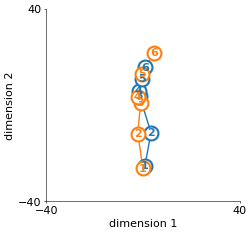

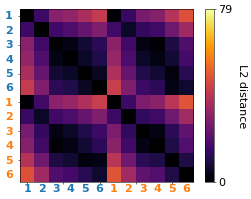

48.40688673252447


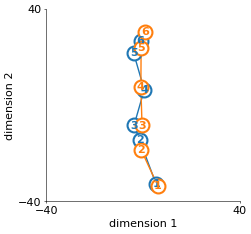

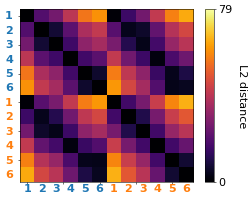

64.99979696972807


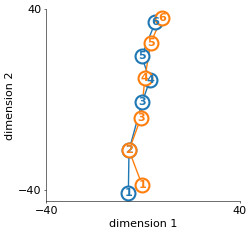

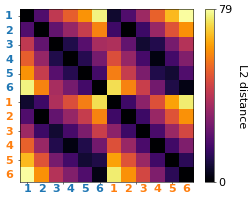

78.54117252324346


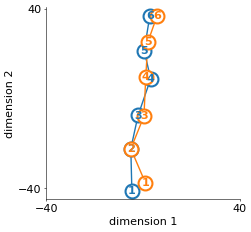

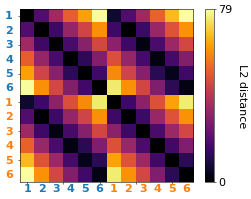

78.54117252324346


In [12]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.utils import shuffle

# Define the number of objects and dimensions
num_objects = 6
input_dim = num_objects
context_dim = 2
hidden_dim = 1000
hidden_context_dim = 1000
output_dim = 100

# Ground truth ranking
ground_truth_ranking1 = [0,1,2,3,4,5]
ground_truth_ranking2 = [0,1,2,3,4,5]

# Create all possible pairs of objects
pairs1 = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
labels1 = [(1 if ground_truth_ranking1.index(i) < ground_truth_ranking1.index(j) else -1) for i, j in pairs1]
pairs2 = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
labels2 = [(1 if ground_truth_ranking2.index(i) < ground_truth_ranking2.index(j) else -1) for i, j in pairs2]

# One-hot encode the input
one_hot_vectors1 = torch.eye(num_objects)
one_hot_vectors2 = torch.eye(num_objects)

one_hot_context = torch.eye(context_dim)

# Initialize W (fixed, random)
# W1 = torch.randn(hidden_dim, input_dim)
# W2 = torch.randn(hidden_dim, input_dim)

# Wc = 10.*torch.randn(hidden_context_dim, context_dim) 
cos=0
W1 = gen_W(num_objects, hidden_dim, cos)
W2 = gen_W(num_objects, hidden_dim, cos)
Wc = gen_W(context_dim, hidden_context_dim, cos)

# Initialize P (trainable)
P = torch.randn(output_dim, hidden_dim+hidden_context_dim) * 0.0001

# Learning rate
eta = 0.1

# Number of epochs
num_epochs = 10

# Define the error function
def error_function(v_i, v_j, label):
    error = torch.sign(torch.maximum((label * (v_i - v_j) +1), torch.tensor(0))*label)
    return error

# Track the mean of v for each object over epochs
mean_v_values1 = np.zeros((num_epochs*len(pairs1)+1, num_objects))
mean_v_values2 = np.zeros((num_epochs*len(pairs1)+1, num_objects))

for i in range(num_objects):
    s_i1_s = W1 @ one_hot_vectors1[i]
    s_i1_c = Wc @ one_hot_context[0]
    v_i1 = P @ torch.concatenate((s_i1_s,s_i1_c))
    mean_v_values1[0, i] = v_i1.mean().item()

    s_i2_s = W2 @ one_hot_vectors2[i]
    s_i2_c = Wc @ one_hot_context[1]
    v_i2 = P @ torch.concatenate((s_i2_s,s_i2_c))
    mean_v_values2[0, i] = v_i2.mean().item()
        
# Training loop
errors = []
iters=0
P_record = []
for epoch in tqdm(range(num_epochs), desc="Training Progress"):
    if epoch in [1,3,5,9]:
        P_record += [P.clone()]
    epoch_error = 0
    pairs2, labels2 = shuffle(pairs2, labels2)
    pairs1, labels1 = shuffle(pairs1, labels1)
    for (i1, j1), label1, (i2, j2), label2 in zip(pairs1, labels1, pairs2, labels2):
        #first linear order
        s_i1_s = W1 @ one_hot_vectors1[i1]
        s_j1_s = W1 @ one_hot_vectors1[j1]
        s_i1_c = Wc @ one_hot_context[0]
        s_j1_c = Wc @ one_hot_context[0]
        
        s_i1 = torch.concatenate((s_i1_s,s_i1_c))
        s_j1 = torch.concatenate((s_j1_s,s_i1_c))

        v_i1 = P @ s_i1
        v_j1 = P @ s_j1

        e1 = error_function(v_i1, v_j1, label1)
        epoch_error += e1.mean().item()
        P += eta * torch.outer(e1, (s_j1-s_i1))
        
        #second linear order
        s_i2_s = W2 @ one_hot_vectors2[i2]
        s_j2_s = W2 @ one_hot_vectors2[j2]
        s_i1_c = Wc @ one_hot_context[1]
        s_j1_c = Wc @ one_hot_context[1]
        
        s_i2 = torch.concatenate((s_i2_s,s_i2_c))
        s_j2 = torch.concatenate((s_j2_s,s_i2_c))


        v_i2 = P @ s_i2
        v_j2 = P @ s_j2

        e2 = error_function(v_i2, v_j2, label2)
        epoch_error += e2.mean().item()

        P += eta * torch.outer(e2, (s_j2-s_i2))
        # Compute the mean v values for each object
        for i in range(num_objects):
            s_i1_s = W1 @ one_hot_vectors1[i]
            s_i1_c = Wc @ one_hot_context[0]
            v_i1 = P @ torch.concatenate((s_i1_s,s_i1_c))
            mean_v_values1[iters+1, i] = v_i1.mean().item()

            s_i2_s = W2 @ one_hot_vectors2[i]
            s_i2_c = Wc @ one_hot_context[1]
            v_i2 = P @ torch.concatenate((s_i2_s,s_i2_c))
            mean_v_values2[iters+1, i] = v_i2.mean().item()
        iters+=1

    errors.append(epoch_error / (num_objects*2))



# Print the final results
summed_v_values1 = mean_v_values1[-1, :]
learned_ranking1 = sorted(range(num_objects), key=lambda i: summed_v_values1[i])

summed_v_values2 = mean_v_values2[-1, :]
learned_ranking2 = sorted(range(num_objects), key=lambda i: summed_v_values2[i])

print(f"Ground truth ranking: {ground_truth_ranking1}")
print(f"Learned ranking: {learned_ranking1}")
print(f"Mean v values: {summed_v_values1}")

print(f"Ground truth ranking: {ground_truth_ranking2}")
print(f"Learned ranking: {learned_ranking2}")
print(f"Mean v values: {summed_v_values2}")
max_mds = 0
max_heat = 0 
for P in P_record:
    _mds,output1, output2 = fig_MDS(W1, W2, P, Wc, 10, False)
    if _mds>max_mds:
        max_mds = _mds
    _heat = plot_heat_map(output1, output2, 99, False)
    if _heat>max_heat:
        max_heat = _heat
print(max_mds)
for P in P_record:
    output1, output2 = fig_MDS(W1, W2, P, Wc, round(max_mds, -1))
    plot_heat_map(output1, output2, round(max_heat, 0))

Phase 1 within context:   0%|          | 0/10 [00:00<?, ?it/s]

Phase 2 boundary stacking:   0%|          | 0/10 [00:00<?, ?it/s]

context 1 ground truth [0, 1, 2, 3, 4, 5]
context 1 learned [0, 1, 2, 3, 4, 5]
context 1 mean v [-2.993886   -1.3938657   0.00610505  1.6061329   2.706128    4.00608   ]
context 2 ground truth [0, 1, 2, 3, 4, 5]
context 2 learned [0, 1, 2, 3, 4, 5]
context 2 mean v [-4.0000219e+00 -2.5399923e+00 -1.2799177e+00  4.6712707e-05
  1.3680375e+00  2.8050158e+00]
context 3 ground truth [0, 1, 2, 3, 4, 5]
context 3 learned [0, 1, 2, 3, 4, 5]
context 3 mean v [-3.1291764  -2.0060914  -0.80619997  0.44584396  1.5938693   2.8538556 ]

full global ranking (smaller score is higher rank)
1 context 2 item 1 score -4.000021934509277
2 context 3 item 1 score -3.129176378250122
3 context 1 item 1 score -2.9938859939575195
4 context 2 item 2 score -2.539992332458496
5 context 3 item 2 score -2.006091356277466
6 context 1 item 2 score -1.393865704536438
7 context 2 item 3 score -1.2799177169799805
8 context 3 item 3 score -0.8061999678611755
9 context 2 item 4 score 4.671270653489046e-05
10 context 1 item

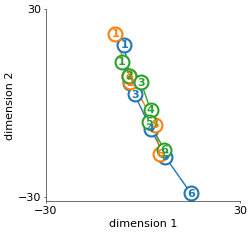

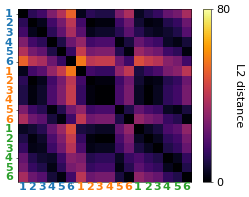

56.06102199454115


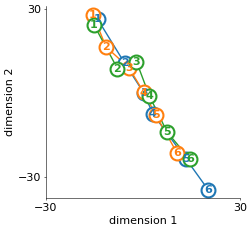

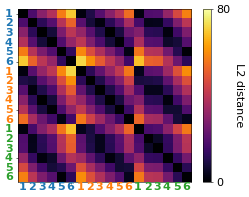

72.06102147879005


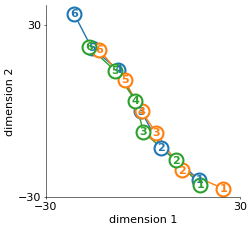

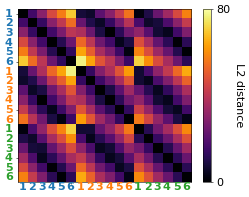

77.03974320854913


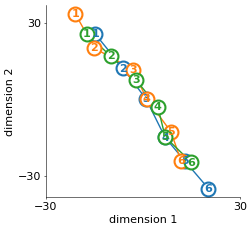

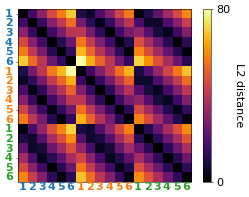

80.06102146873224


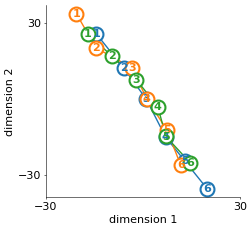

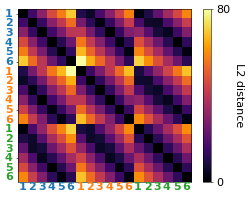

80.06102146873224


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from scipy.spatial.distance import cdist
from sklearn.utils import shuffle
import torch
from tqdm.notebook import tqdm

plt.rcParams.update({'font.size': 16})

def forward(x, W, P, Wc, c):
    # x is (num_objects, num_objects) one hot batch
    # W @ x gives (hidden_dim, num_objects)
    # Wc[:, c] is (hidden_context_dim,)
    # repeat to (hidden_context_dim, num_objects)
    states = torch.concatenate((W @ x, Wc[:, c][None].T.repeat(1, x.shape[1])), dim=0)
    output = (P @ states)  # (output_dim, num_objects)
    return output

def fig_MDS(W_list, P, Wc, scale, plot=True):
    num_contexts = len(W_list)
    list_len = 6
    data = torch.eye(list_len)

    outputs = []
    for c, W in enumerate(W_list):
        outputs.append(forward(data, W, P, Wc, c))

    data_np = np.hstack([o.detach().cpu().numpy() for o in outputs])  # (output_dim, list_len*num_contexts)

    mds = MDS(n_components=2, random_state=0)
    data_2d = mds.fit_transform(data_np.T)
    data_2d[:, [0, 1]] = data_2d[:, [1, 0]]

    if not plot:
        return data_2d.max(), outputs

    colors = ['tab:blue', 'tab:orange', 'tab:green']
    fig, ax = plt.subplots(figsize=(5, 5), dpi=50)
    dot_size = 400
    dot_edge_width = 3

    for c in range(num_contexts):
        start = c * list_len
        end = (c + 1) * list_len
        for i in range(start + 1, end):
            ax.plot(data_2d[i-1:i+1, 0], data_2d[i-1:i+1, 1], color=colors[c], linewidth=2, zorder=1)

        for i, point in enumerate(data_2d[start:end, :]):
            ax.scatter(point[0], point[1], s=dot_size, edgecolor=colors[c], facecolor='white',
                       linewidth=dot_edge_width, zorder=2)
            ax.text(point[0], point[1], str(i+1), color=colors[c], ha='center', va='center',
                    fontweight='bold', zorder=3)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ticks = [-scale, scale]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    plt.xlabel('dimension 1')
    plt.ylabel('dimension 2')
    plt.show()

    return outputs

def plot_heat_map(outputs, max_v, plot=True):
    # outputs is list of (output_dim, list_len)
    list_len = outputs[0].shape[1]
    num_contexts = len(outputs)
    labels = []
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    for c in range(num_contexts):
        labels += [str(i+1) for i in range(list_len)]

    all_data = np.concatenate([o.detach().cpu().numpy() for o in outputs], axis=1)  # (output_dim, list_len*num_contexts)
    distances = cdist(all_data.T, all_data.T, 'euclidean')
    np.fill_diagonal(distances, 0)

    if not plot:
        return distances.max()

    fig, ax = plt.subplots(figsize=(4*1.5, 3*1.5), dpi=50)
    heatmap = ax.imshow(distances, cmap='inferno', origin='upper', vmin=0, vmax=max_v)

    cbar = fig.colorbar(heatmap, ticks=[0, max_v])
    cbar.set_label('L2 distance', rotation=270, labelpad=20)

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    n = list_len * num_contexts

    for idx, lab in enumerate(labels):
        c = idx // list_len
        ax.text(idx, n, lab, va='center', ha='center', color=colors[c], fontweight='bold')
        ax.text(-1, idx, lab, va='center', ha='right', color=colors[c], fontweight='bold')

    ax.grid(False)
    plt.show()
    print(distances.max())

def average_cosine(vectors):
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)
    cosine_sim = vectors_norm @ vectors_norm.T
    n = vectors.shape[0]
    i, j = torch.triu_indices(n, n, offset=1)
    return cosine_sim[i, j].mean().item()

def gen_W(num_objects, dim, target_cosine):
    sparsity_range = (0.002, 0.01)
    vectors = torch.zeros((num_objects, dim), dtype=torch.float)
    num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
    for i in range(num_objects):
        ones_indices = torch.randperm(dim)[:num_ones[i]]
        vectors[i, ones_indices] = 1

    cos = average_cosine(vectors)
    if target_cosine == 0 and cos != 0:
        vectors = torch.zeros((num_objects, dim), dtype=torch.float)
        num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
        for i in range(num_objects):
            ones_indices = torch.randperm(dim)[:num_ones[i]]
            vectors[i, ones_indices] = 1
        cos = average_cosine(vectors)

    while cos < target_cosine:
        indices = torch.randperm(num_objects)[:2]
        i, j = indices[0], indices[1]
        vi = vectors[i, :]
        vj = vectors[j, :]

        diff_indices = torch.nonzero(vi.int() ^ vj.int()).flatten()
        if len(diff_indices) == 0:
            continue

        dim_to_change = diff_indices[torch.randint(len(diff_indices), (1,)).item()]
        index_to_modify = i if vi[dim_to_change] == 0 else j
        vectors[index_to_modify, dim_to_change] = 1

        ones_indices = torch.nonzero(vectors[index_to_modify] == 1).flatten()
        ones_indices = ones_indices[ones_indices != dim_to_change]
        dim_to_zero = ones_indices[torch.randint(len(ones_indices), (1,)).item()]
        vectors[index_to_modify, dim_to_zero] = 0

        cos = average_cosine(vectors)

    return vectors.T

def error_function(v_i, v_j, label):
    # label in {+1, -1}
    # hinge margin 1, then turn it into sign style update like your code
    return torch.sign(torch.maximum((label * (v_i - v_j) + 1), torch.tensor(0.0, device=v_i.device)) * label)

def mean_score(W, P, Wc, c, num_objects):
    one_hot = torch.eye(num_objects)
    out = forward(one_hot, W, P, Wc, c)  # (output_dim, num_objects)
    return out.mean(dim=0)  # (num_objects,)

torch.manual_seed(0)
np.random.seed(0)

num_objects = 6
num_contexts = 3
input_dim = num_objects
context_dim = num_contexts
hidden_dim = 1000
hidden_context_dim = 1000
output_dim = 100

ground_truth_rankings = [
    [0, 1, 2, 3, 4, 5],
    [0, 1, 2, 3, 4, 5],
    [0, 1, 2, 3, 4, 5],
]

pairs = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
labels_by_context = []
for r in ground_truth_rankings:
    labels_by_context.append([(1 if r.index(i) < r.index(j) else -1) for i, j in pairs])

one_hot_context = torch.eye(context_dim)

cos = 0
W_list = [gen_W(num_objects, hidden_dim, cos) for _ in range(num_contexts)]
Wc = gen_W(context_dim, hidden_context_dim, cos)

P = torch.randn(output_dim, hidden_dim + hidden_context_dim) * 0.0001

eta = 0.1
eta_c = 2  # boundary phase, context shift is stronger

num_epochs_phase1 = 10
num_epochs_phase2 = 10

mean_v_values = [np.zeros((num_epochs_phase1 * len(pairs) + 1, num_objects)) for _ in range(num_contexts)]

for c in range(num_contexts):
    mv = mean_score(W_list[c], P, Wc, c, num_objects).detach().cpu().numpy()
    mean_v_values[c][0, :] = mv

iters = 0
P_record = []

for epoch in tqdm(range(num_epochs_phase1), desc="Phase 1 within context"):
    if epoch in [1, 3, 5, 9]:
        P_record.append(P.clone())

    shuffled = []
    for c in range(num_contexts):
        pp, ll = shuffle(pairs, labels_by_context[c])
        shuffled.append((pp, ll))

    for k in range(len(pairs)):
        for c in range(num_contexts):
            (i, j) = shuffled[c][0][k]
            label = shuffled[c][1][k]

            one_hot = torch.eye(num_objects)
            s_i_s = W_list[c] @ one_hot[i]
            s_j_s = W_list[c] @ one_hot[j]
            s_c = Wc @ one_hot_context[c]

            s_i = torch.concatenate((s_i_s, s_c))
            s_j = torch.concatenate((s_j_s, s_c))

            v_i = P @ s_i
            v_j = P @ s_j

            e = error_function(v_i, v_j, label)
            P += eta * torch.outer(e, (s_j - s_i))

        for c in range(num_contexts):
            mv = mean_score(W_list[c], P, Wc, c, num_objects).detach().cpu().numpy()
            mean_v_values[c][iters + 1, :] = mv
        iters += 1

P_record.append(P.clone())

# Phase 2 boundary pairs, update Wc only to stack contexts into one global rank
# Goal is context 2 above context 1, context 3 above context 2
# In score terms, "above" means smaller scores, because label=+1 tries to make v_i < v_j by margin 1
boundary_pairs = [
    # context 2 beats context 1
    {"c_hi": 1, "i_hi": 5, "c_lo": 0, "i_lo": 0, "label": 1},
    # context 3 beats context 2
    {"c_hi": 2, "i_hi": 5, "c_lo": 1, "i_lo": 0, "label": 1},
]

for epoch in tqdm(range(num_epochs_phase2), desc="Phase 2 boundary stacking"):
    for _ in range(len(pairs)):
        for bp in boundary_pairs:
            c_hi, i_hi = bp["c_hi"], bp["i_hi"]
            c_lo, i_lo = bp["c_lo"], bp["i_lo"]
            label = bp["label"]

            one_hot = torch.eye(num_objects)
            s_hi_s = W_list[c_hi] @ one_hot[i_hi]
            s_lo_s = W_list[c_lo] @ one_hot[i_lo]

            s_hi_c = Wc @ one_hot_context[c_hi]
            s_lo_c = Wc @ one_hot_context[c_lo]

            s_hi = torch.concatenate((s_hi_s, s_hi_c))
            s_lo = torch.concatenate((s_lo_s, s_lo_c))

            v_hi = P @ s_hi
            v_lo = P @ s_lo

            e = error_function(v_hi, v_lo, label)

            grad_s = (P.T @ e)  # (hidden_dim + hidden_context_dim,)
            grad_c = grad_s[hidden_dim:]  # only context part

            # make hi context globally smaller, make lo context globally larger
            Wc[:, c_hi] -= eta_c * grad_c
            Wc[:, c_lo] += eta_c * grad_c

# Evaluate separate ranks and full combined rank
for c in range(num_contexts):
    scores = mean_score(W_list[c], P, Wc, c, num_objects).detach().cpu().numpy()
    learned = sorted(range(num_objects), key=lambda i: scores[i])
    print("context", c + 1, "ground truth", ground_truth_rankings[c])
    print("context", c + 1, "learned", learned)
    print("context", c + 1, "mean v", scores)

all_items = []
for c in range(num_contexts):
    scores = mean_score(W_list[c], P, Wc, c, num_objects).detach().cpu().numpy()
    for i in range(num_objects):
        all_items.append((scores[i], c, i))
all_items_sorted = sorted(all_items, key=lambda x: x[0])

print("\nfull global ranking (smaller score is higher rank)")
for rank_pos, (s, c, i) in enumerate(all_items_sorted, start=1):
    print(rank_pos, "context", c + 1, "item", i + 1, "score", float(s))

# Visualize last few checkpoints using current Wc
max_mds = 0
max_heat = 0
for Ptmp in P_record:
    _mds, outs = fig_MDS(W_list, Ptmp, Wc, 10, plot=False)
    max_mds = max(max_mds, _mds)
    _heat = plot_heat_map(outs, 99, plot=False)
    max_heat = max(max_heat, _heat)

print("max mds", max_mds)
for Ptmp in P_record:
    outs = fig_MDS(W_list, Ptmp, Wc, round(max_mds, -1), plot=True)
    plot_heat_map(outs, round(max_heat, 0), plot=True)


Phase 1 training (3 contexts):   0%|          | 0/10 [00:00<?, ?it/s]

Phase 1
ctx1 learned: [0, 1, 2, 3, 4, 5] mean v: [-2.28401923 -1.15202343  0.04995164  1.70993876  3.18492794  4.5249877 ]
ctx2 learned: [0, 1, 2, 3, 4, 5] mean v: [-4.39993    -2.79199505 -1.12001526  0.37795913  1.59397709  2.92195916]
ctx3 learned: [0, 1, 2, 3, 4, 5] mean v: [-3.51392913 -2.05495763 -0.7439993   0.4999831   1.70502698  2.85001254]


Phase 2 boundary stacking (3 contexts):   0%|          | 0/6 [00:00<?, ?it/s]

Phase 2
ctx1 learned: [0, 1, 2, 3, 4, 5] mean v: [-13.08401871 -11.95202351 -10.75004864  -9.09006119  -7.61507225
  -6.57501221]
ctx2 learned: [0, 1, 2, 3, 4, 5] mean v: [-3.91992974 -2.79199505 -1.12001526  0.37795913  1.59397709  2.50195885]
ctx3 learned: [0, 1, 2, 3, 4, 5] mean v: [ 5.30607128  6.28504276  7.65600014  8.89998245 10.1050272  11.2500124 ]
Global rank (small mean v = higher)
1 ctx 1 item 1 mean_v -13.08401870727539
2 ctx 1 item 2 mean_v -11.95202350616455
3 ctx 1 item 3 mean_v -10.750048637390137
4 ctx 1 item 4 mean_v -9.09006118774414
5 ctx 1 item 5 mean_v -7.615072250366211
6 ctx 1 item 6 mean_v -6.57501220703125
7 ctx 2 item 1 mean_v -3.9199297428131104
8 ctx 2 item 2 mean_v -2.791995048522949
9 ctx 2 item 3 mean_v -1.120015263557434
10 ctx 2 item 4 mean_v 0.37795913219451904
11 ctx 2 item 5 mean_v 1.5939770936965942
12 ctx 2 item 6 mean_v 2.5019588470458984
13 ctx 3 item 1 mean_v 5.3060712814331055
14 ctx 3 item 2 mean_v 6.285042762756348
15 ctx 3 item 3 mean_v 7.

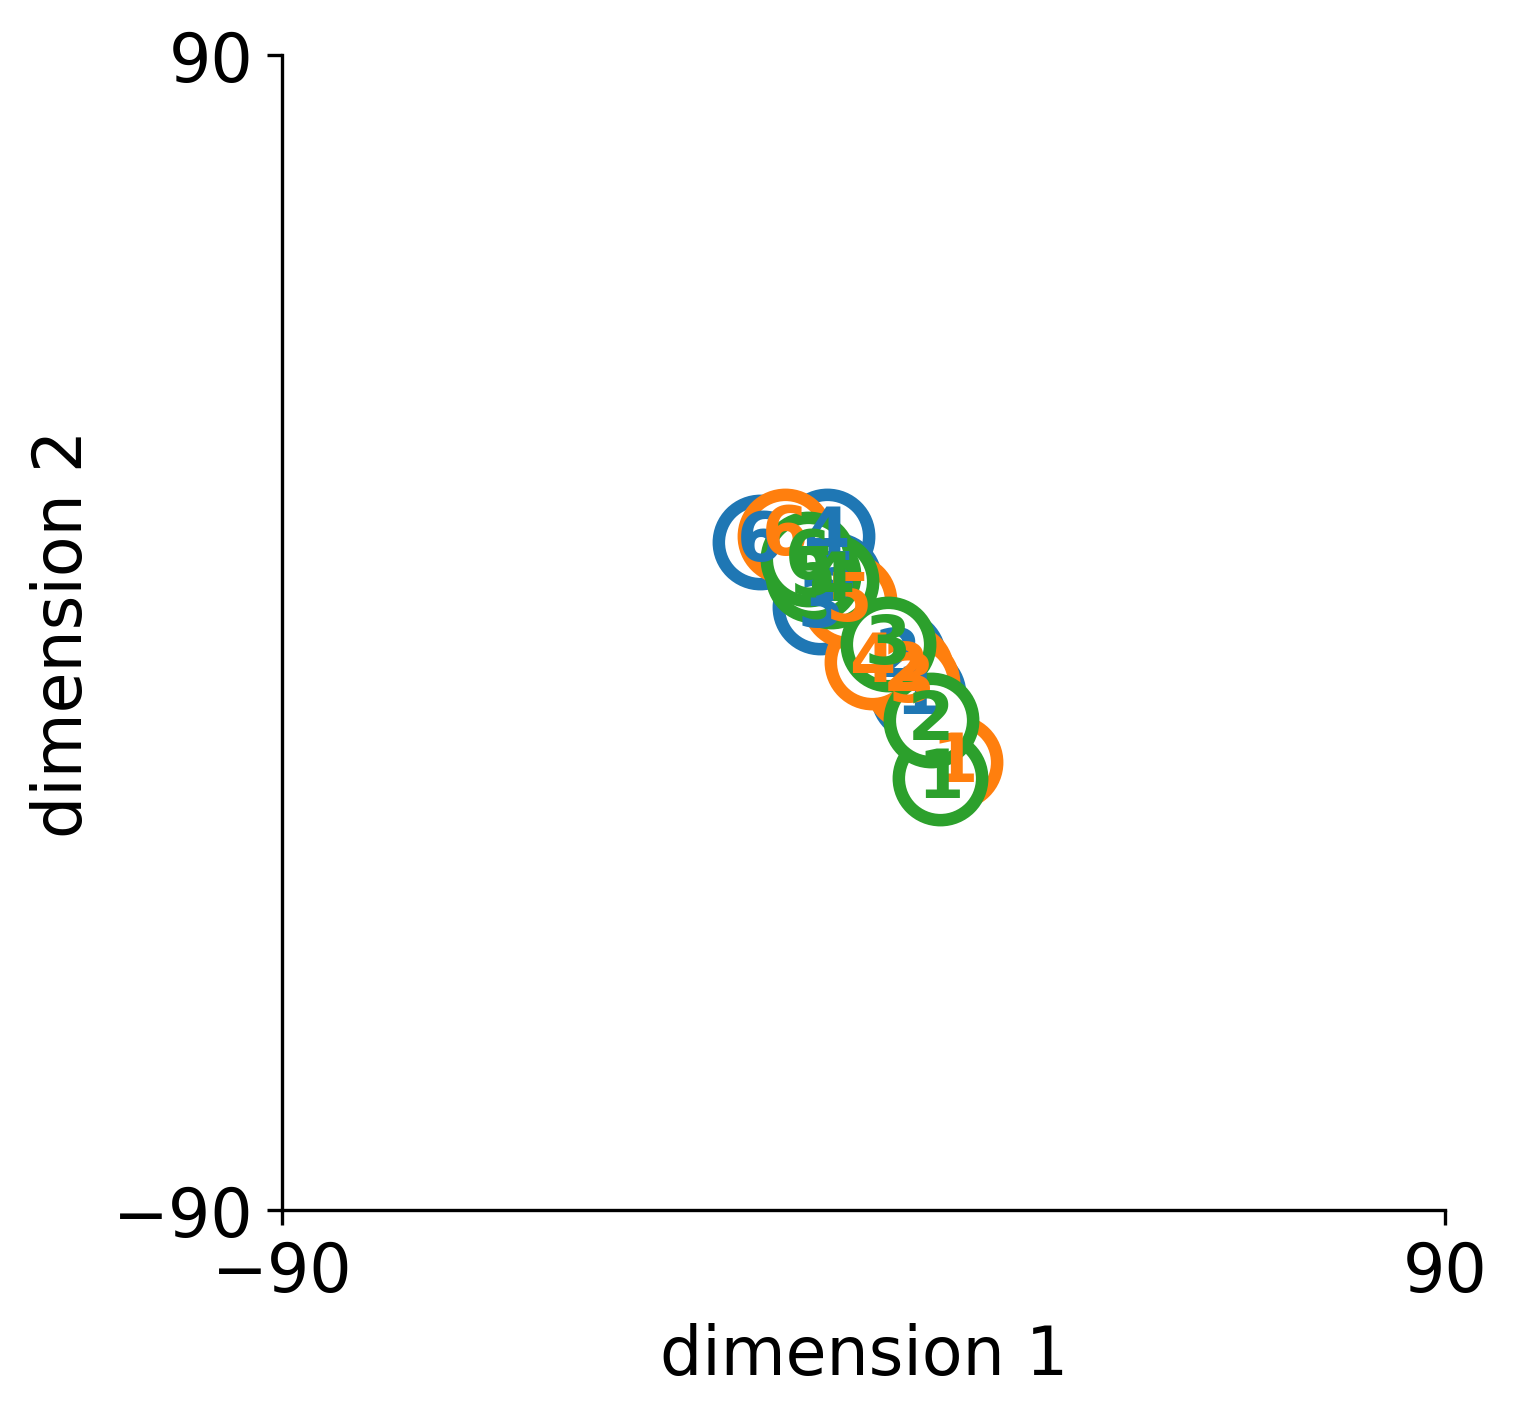

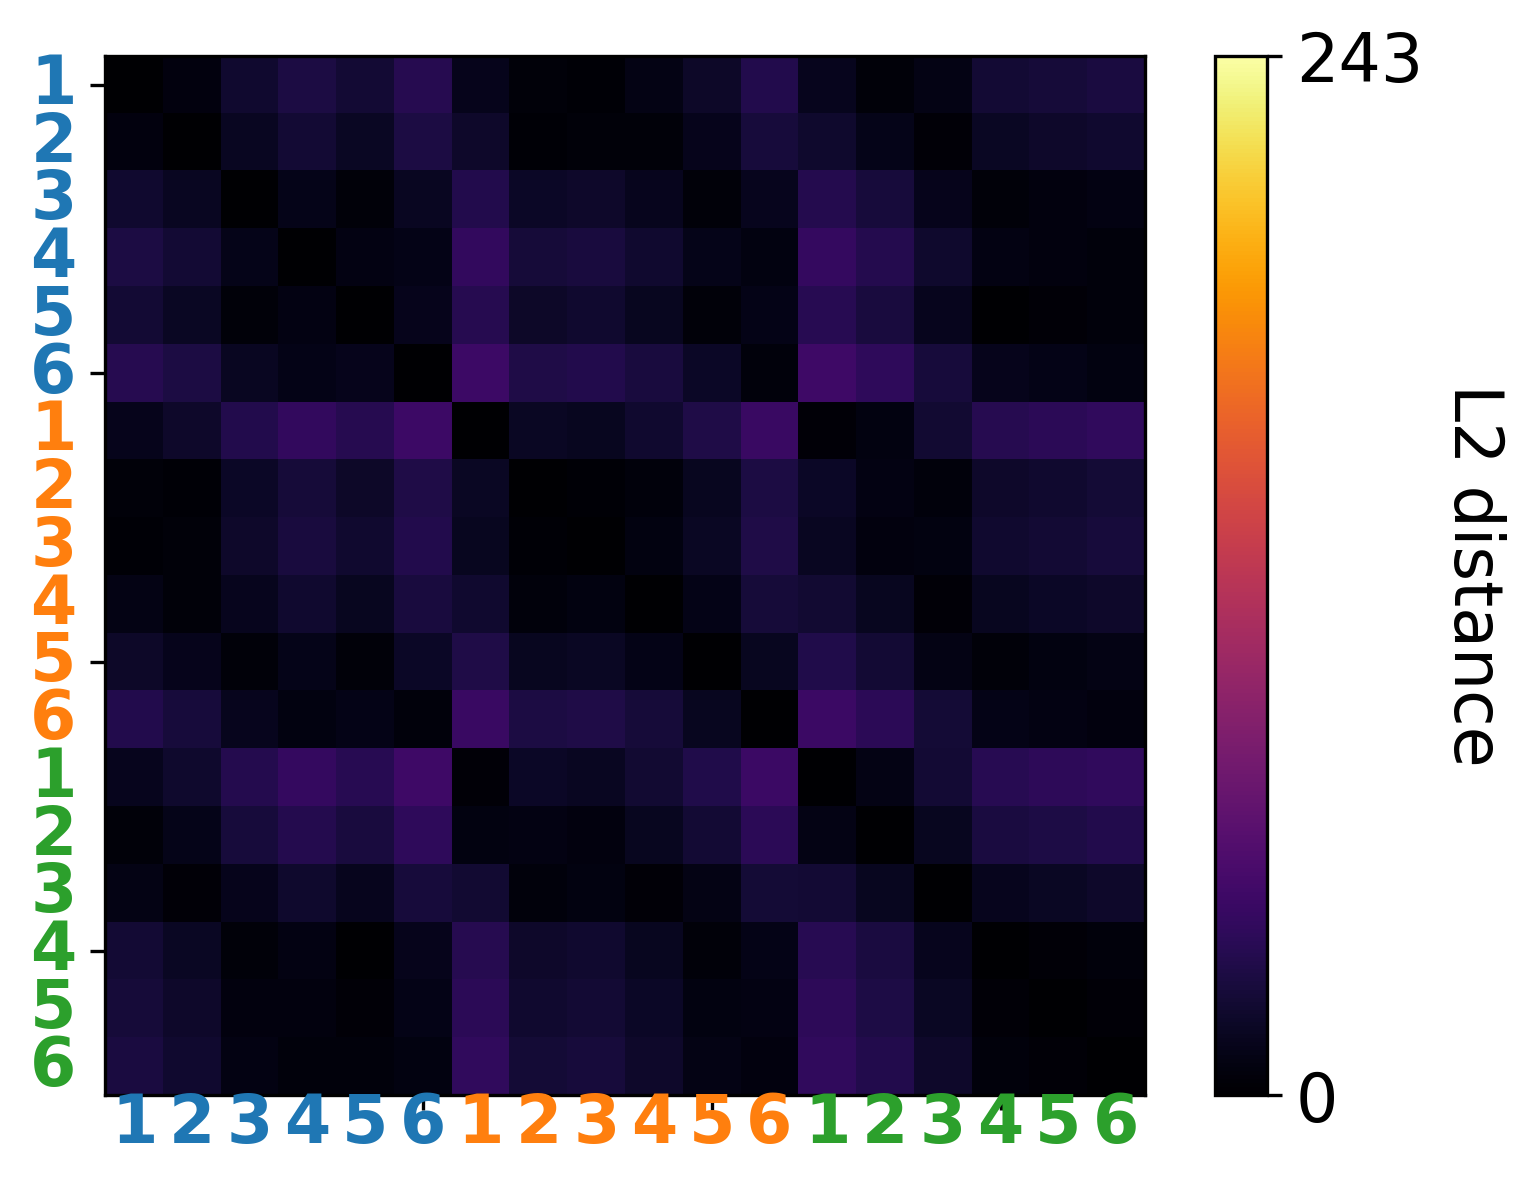

46.97077998467564


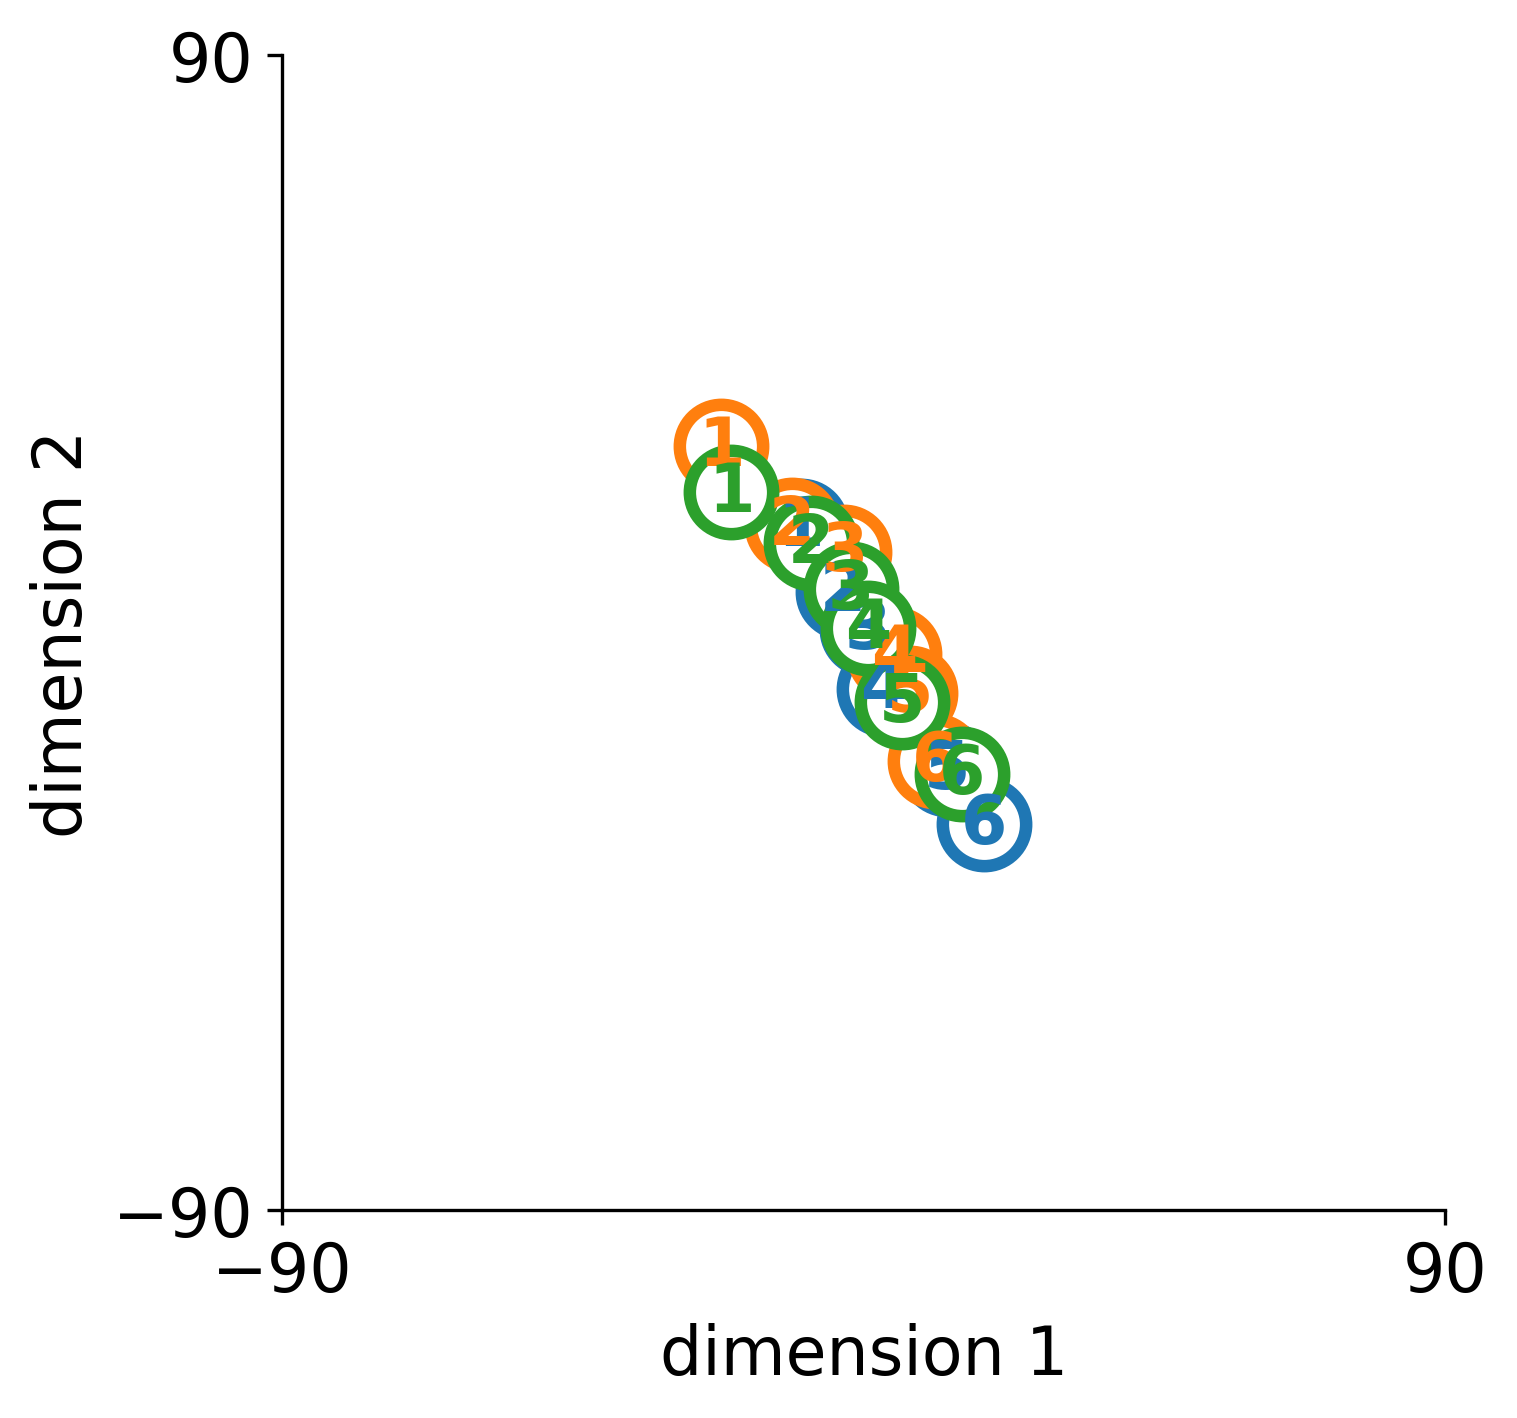

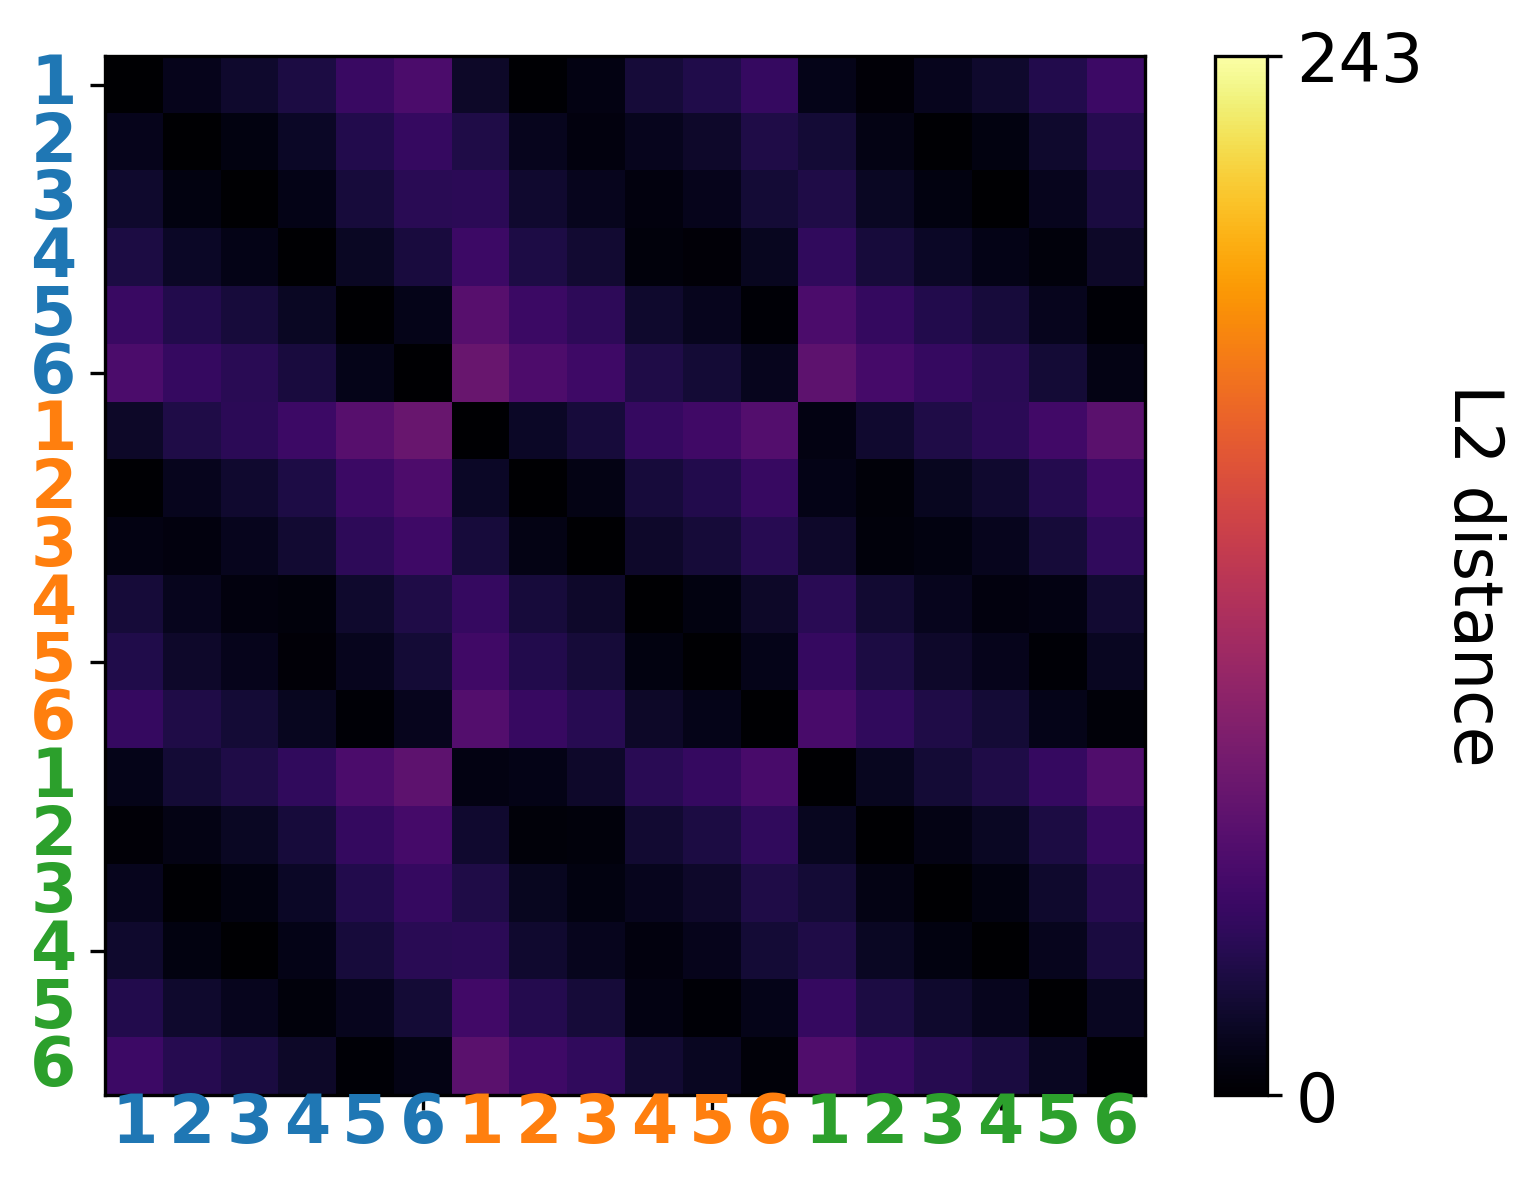

71.37005847766073


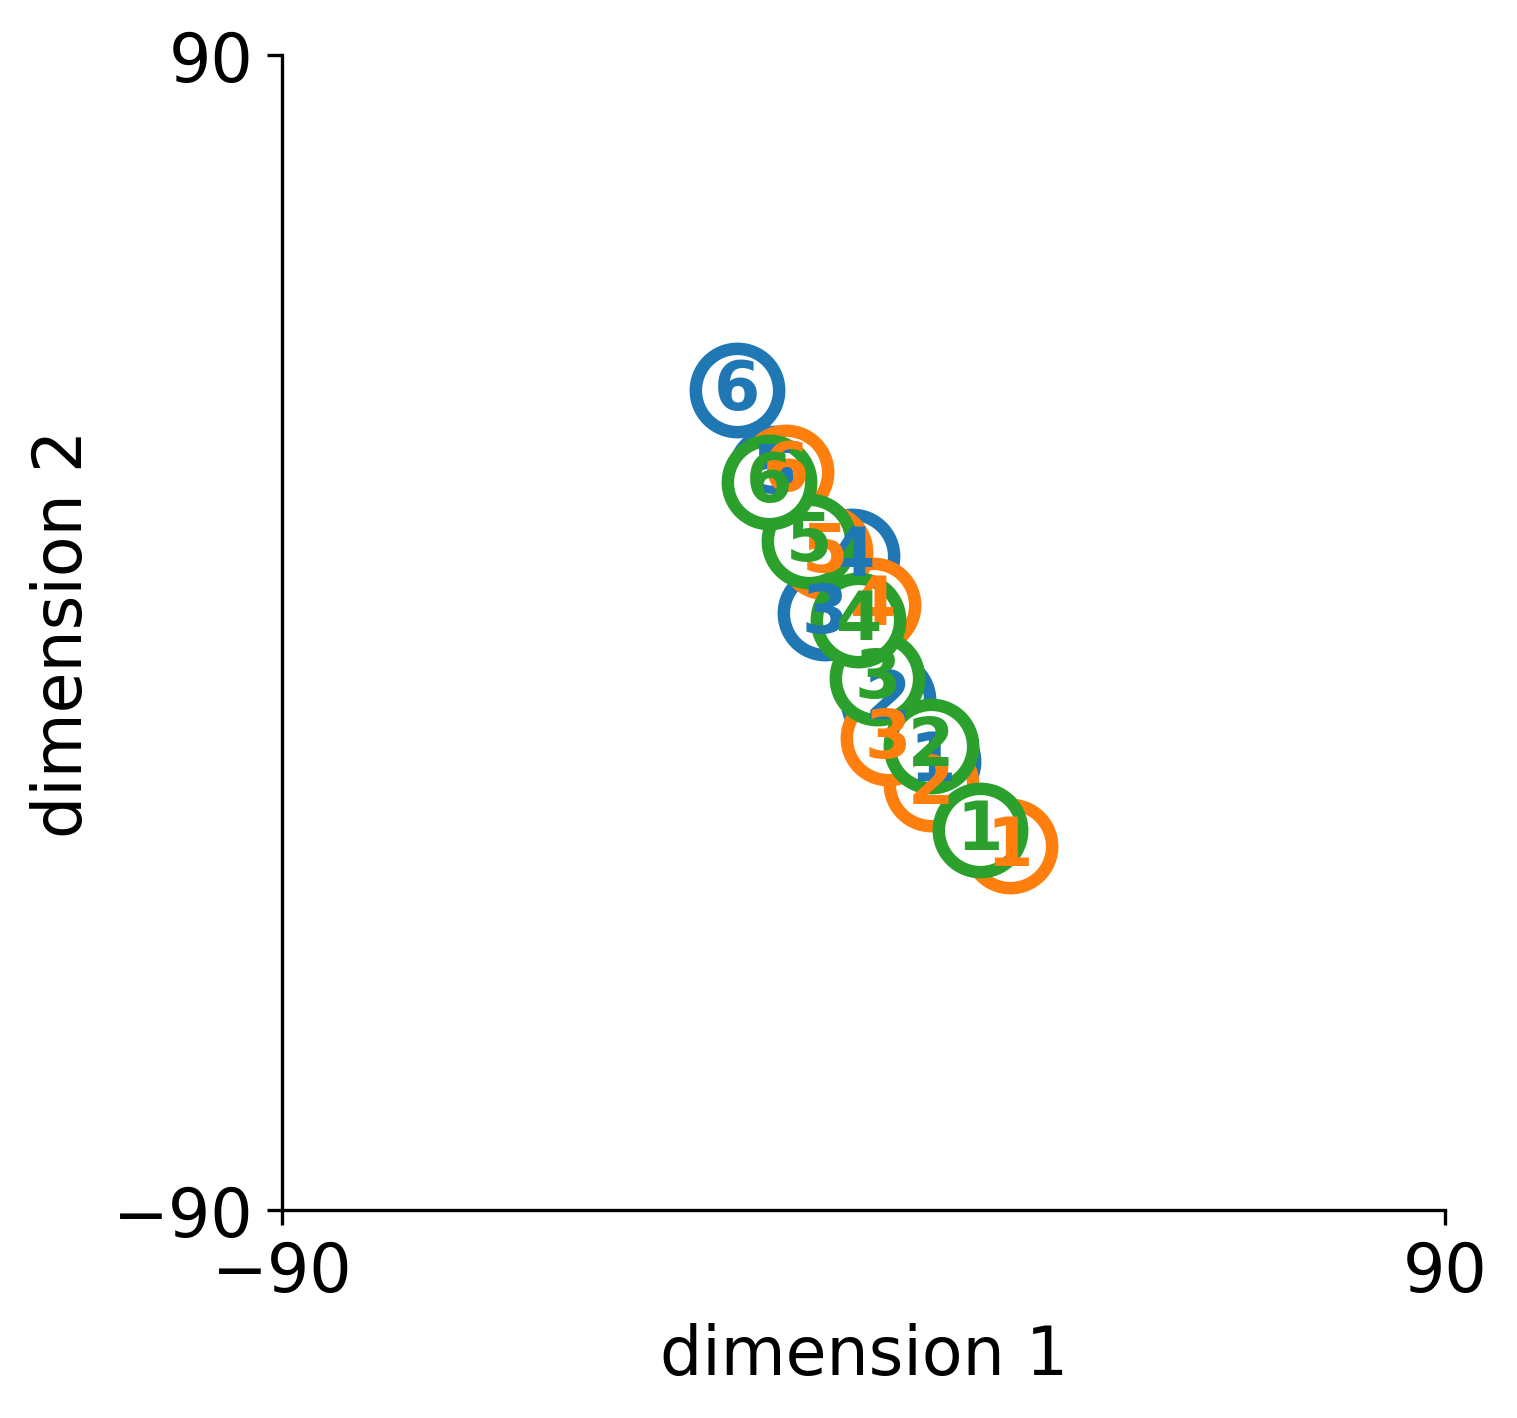

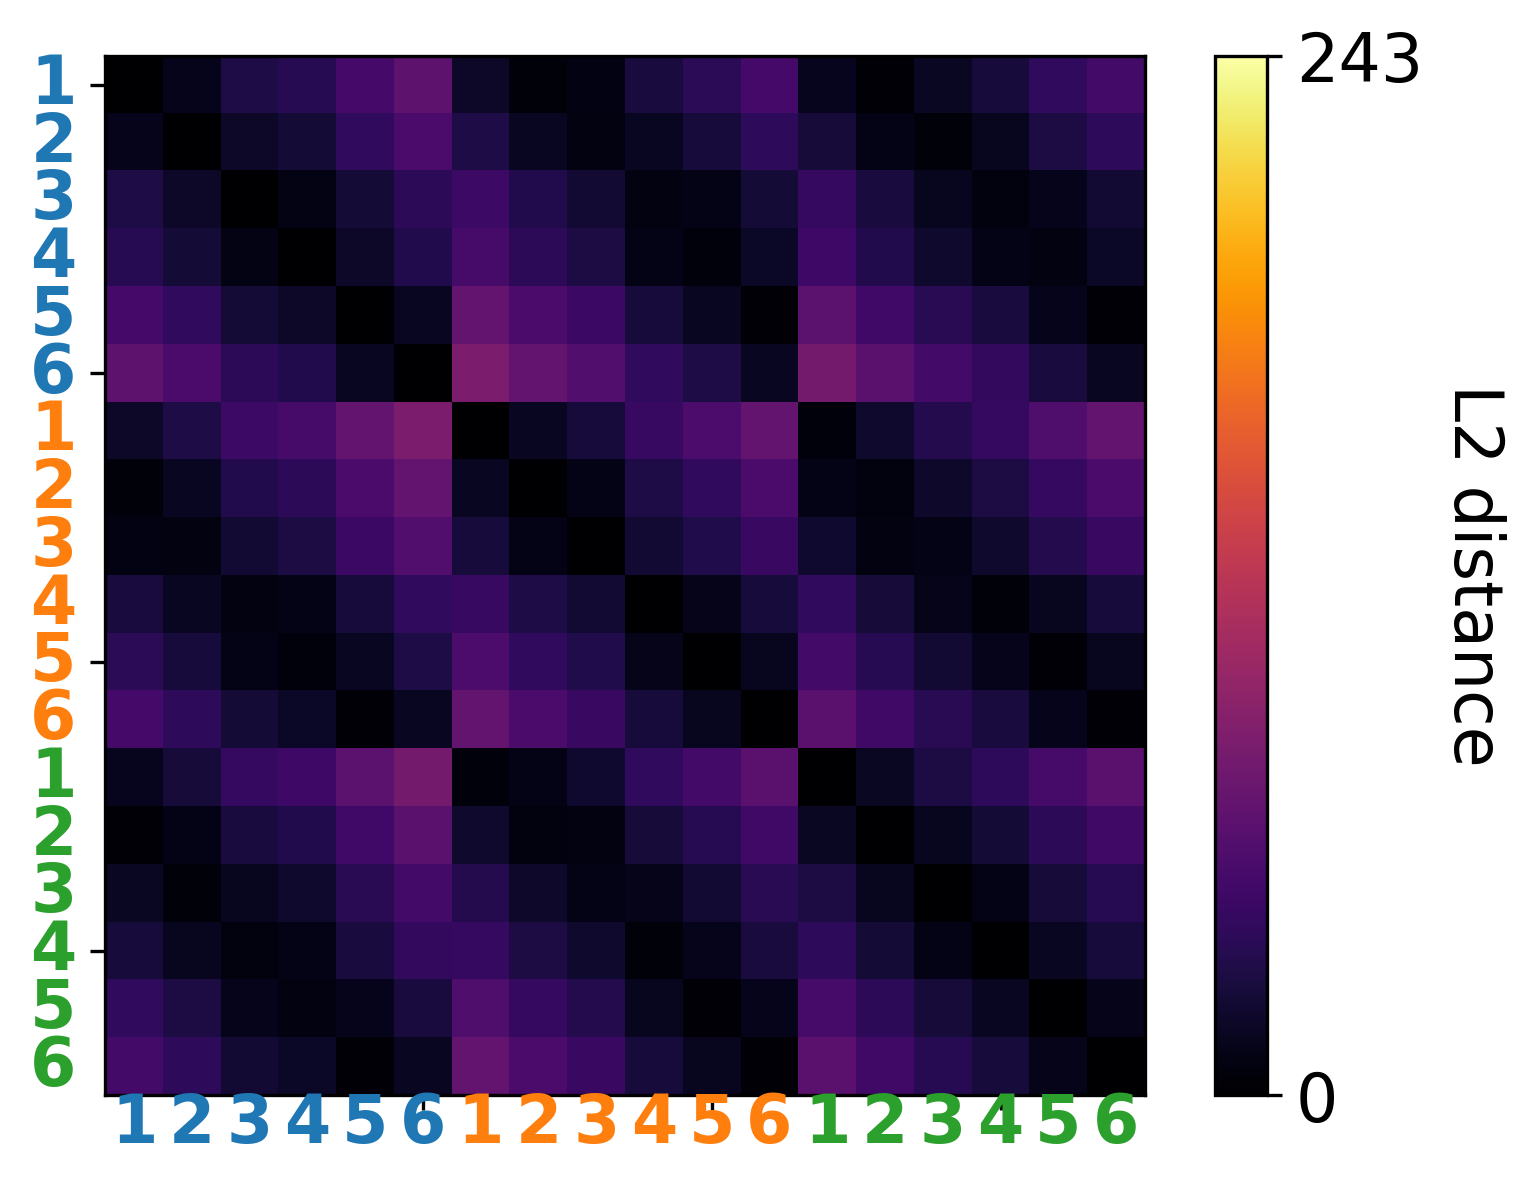

82.67683455940204


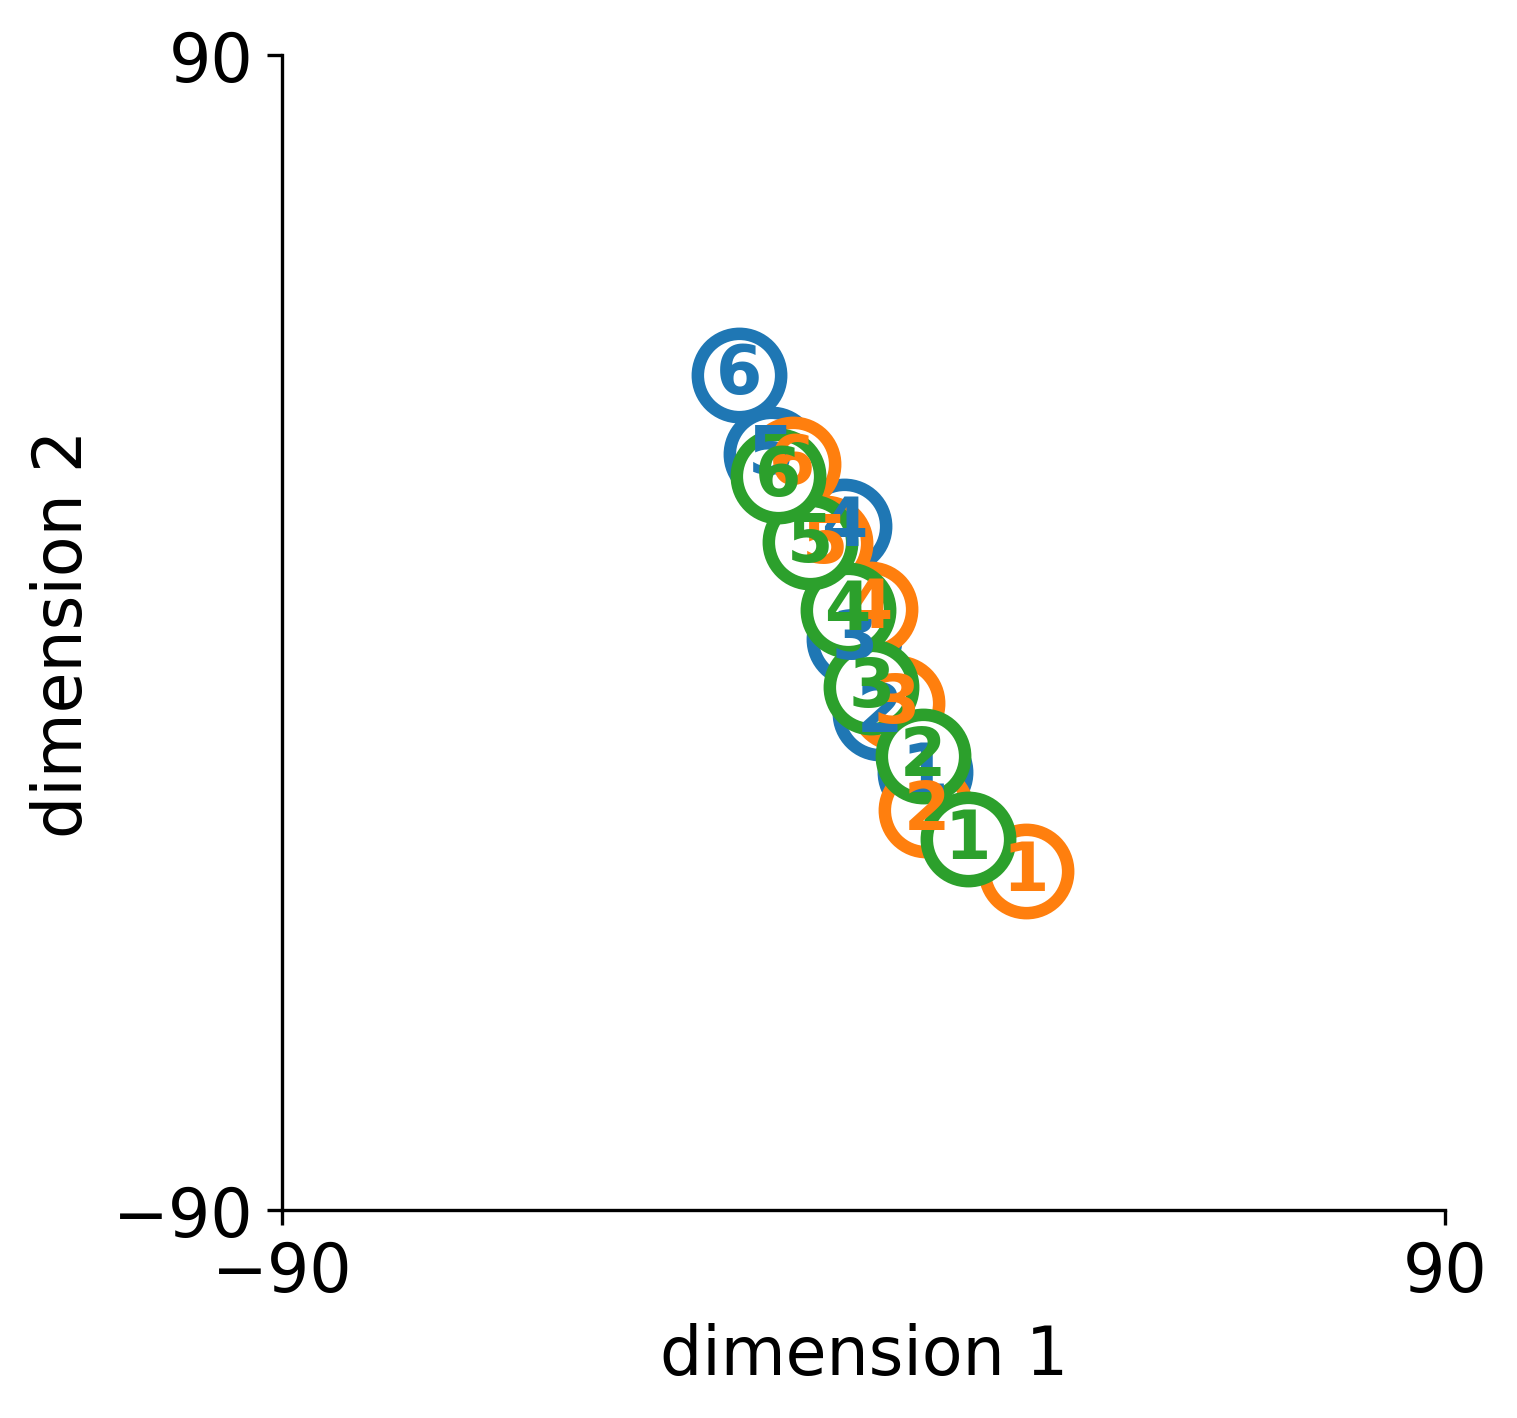

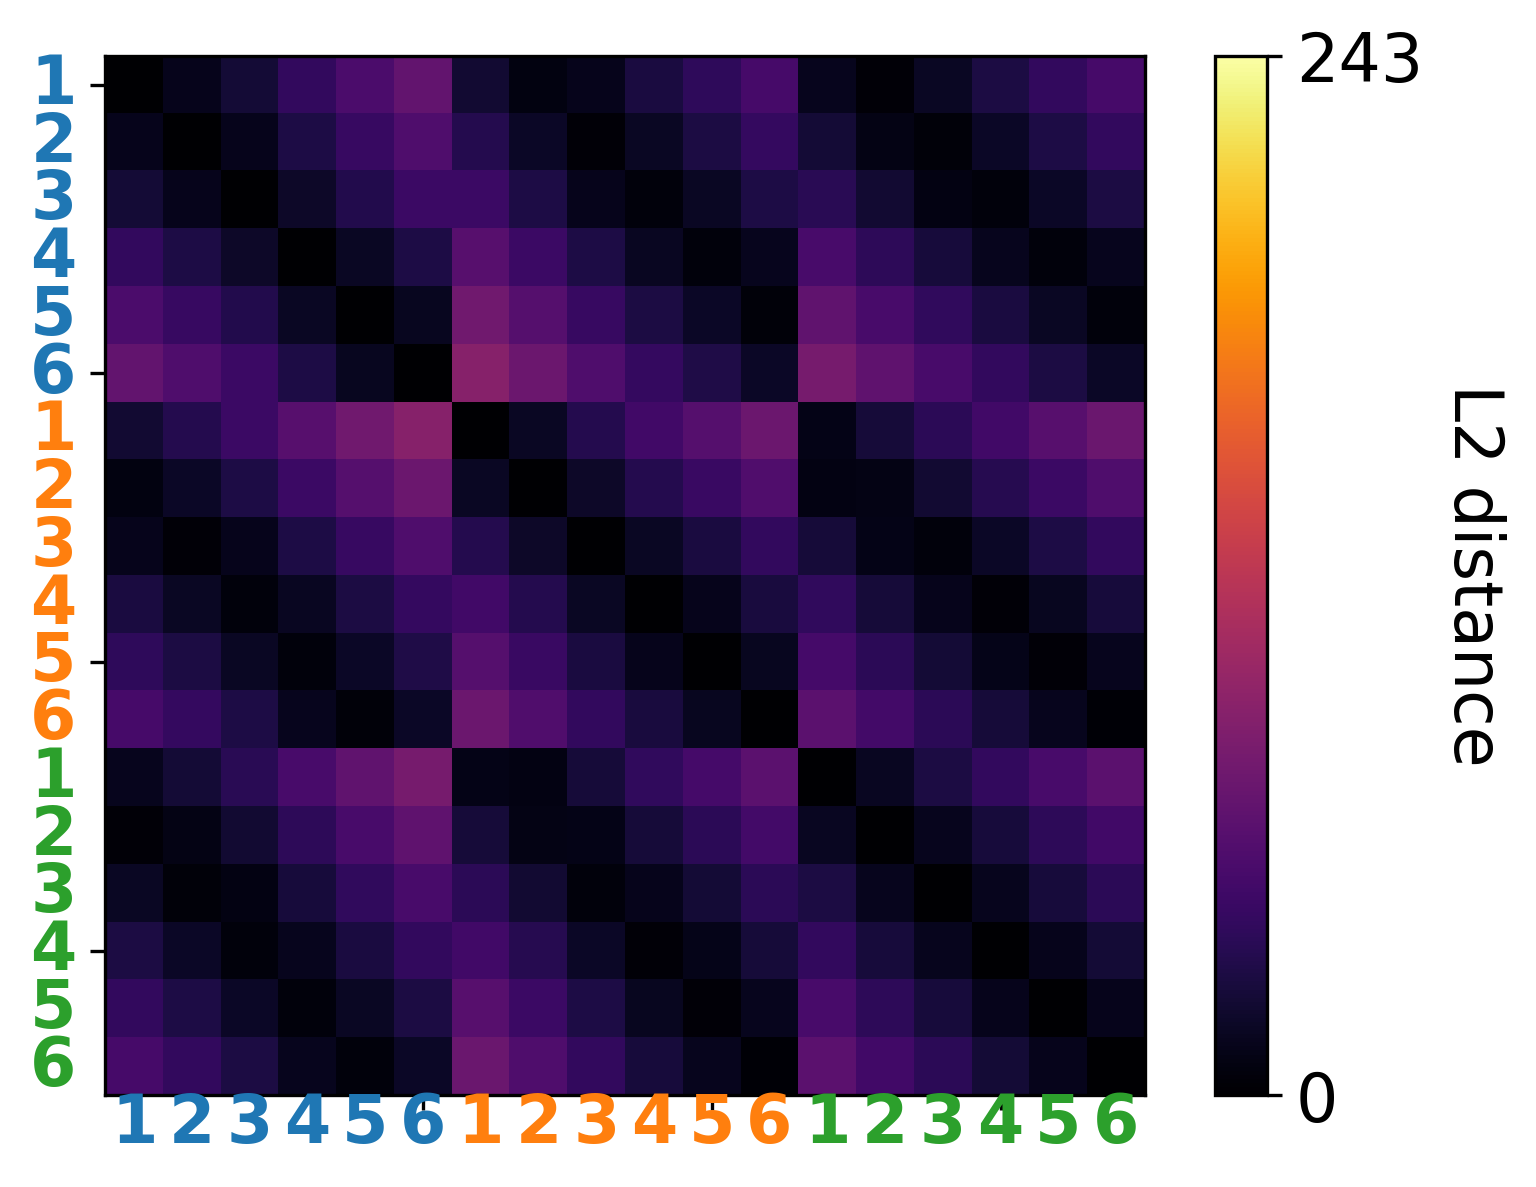

89.41153885187356


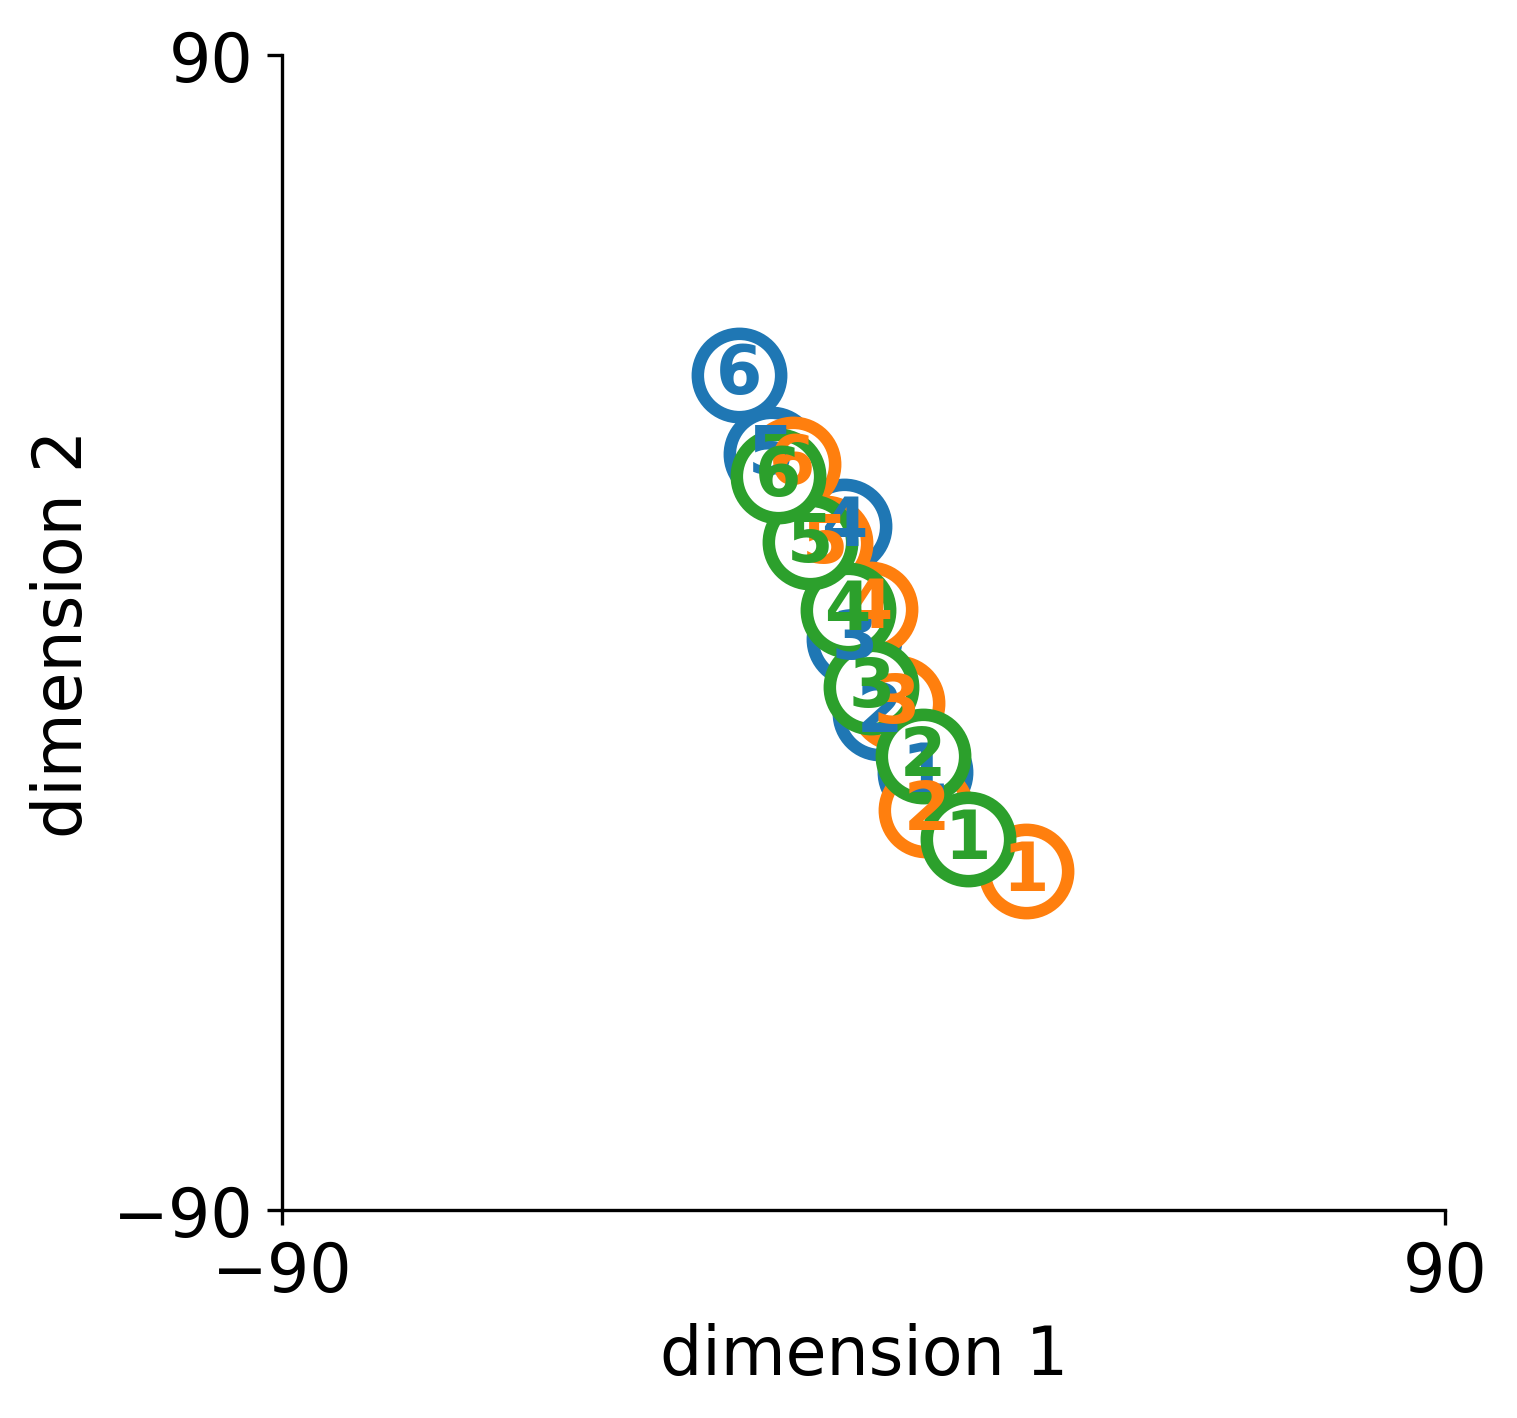

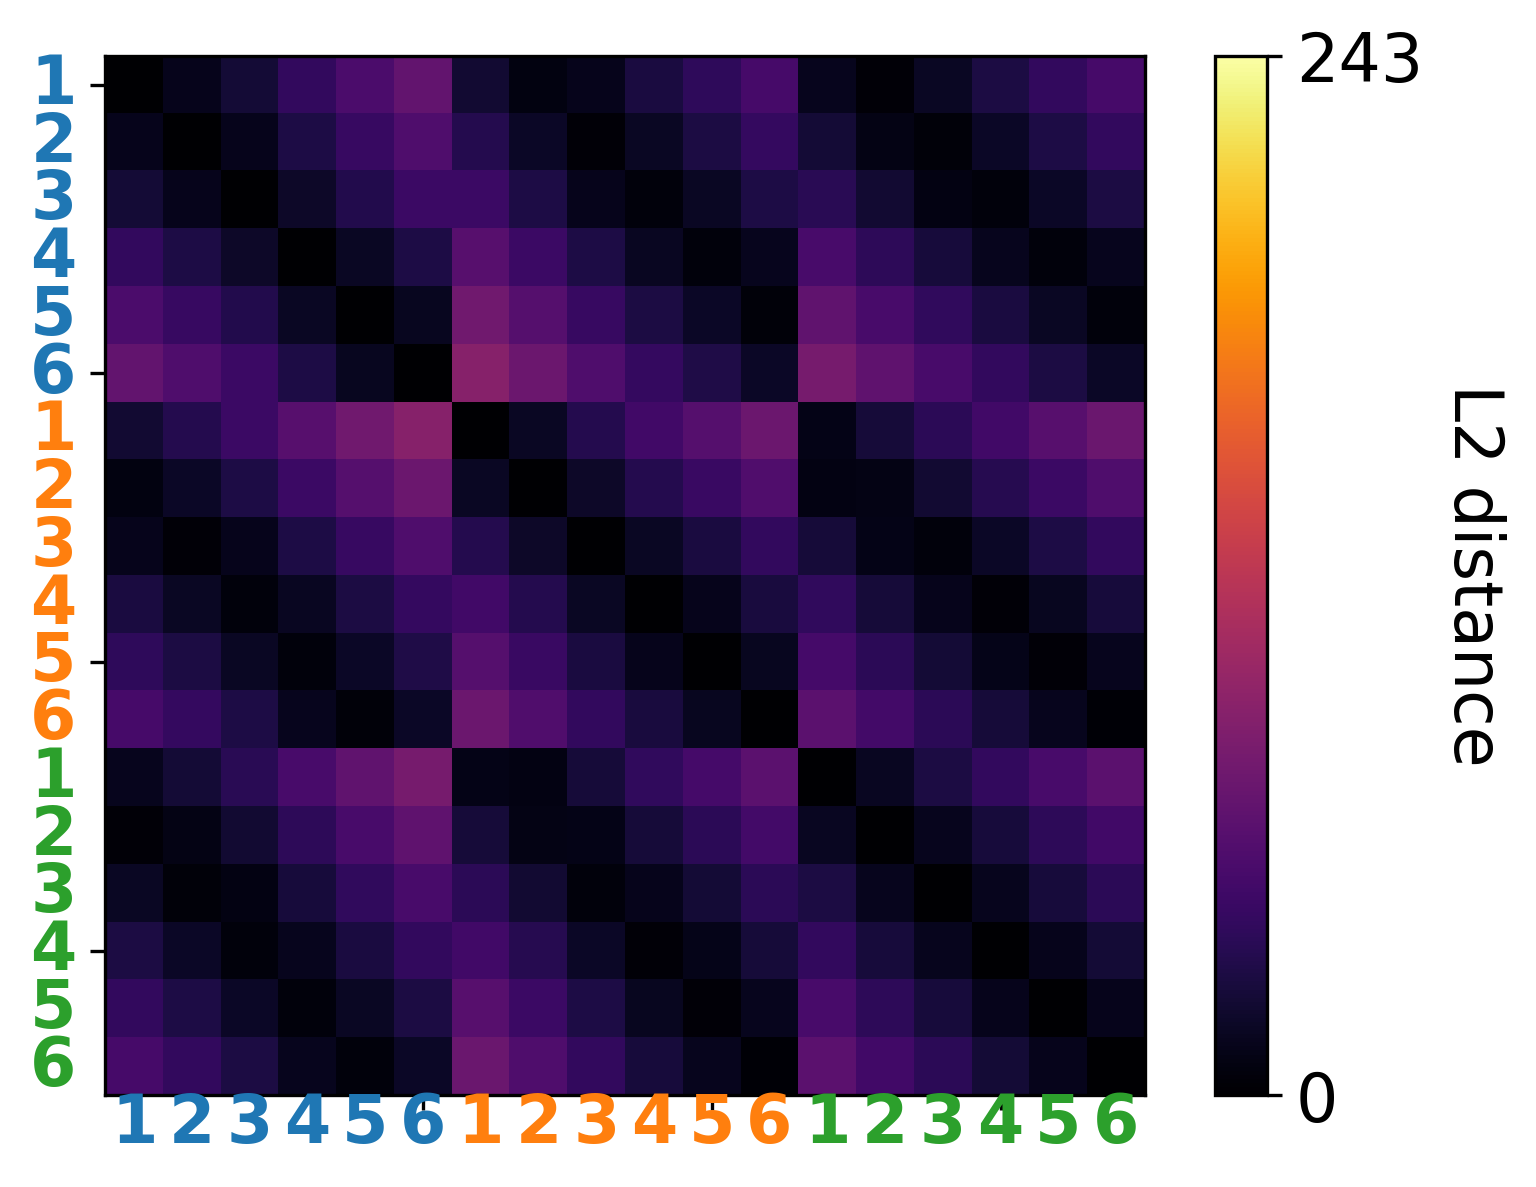

89.41153885187356


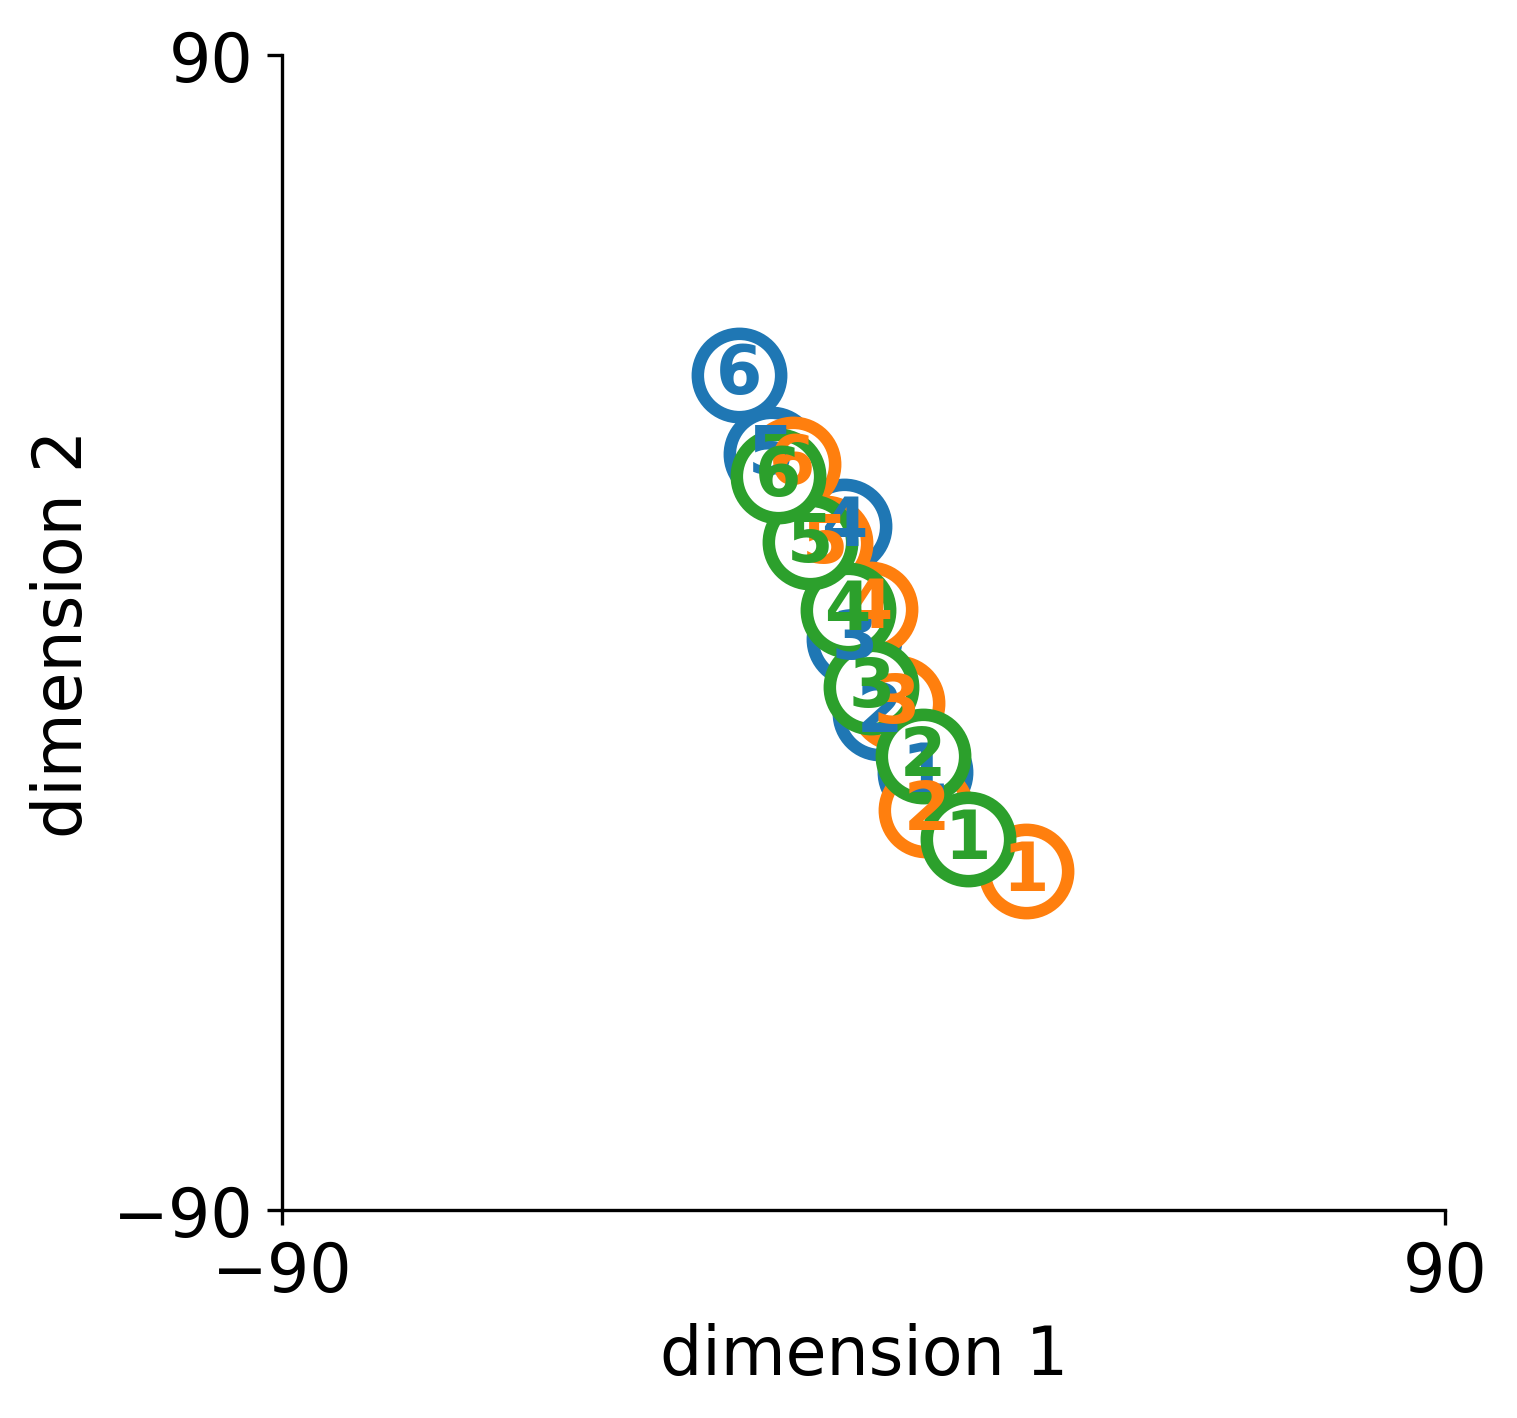

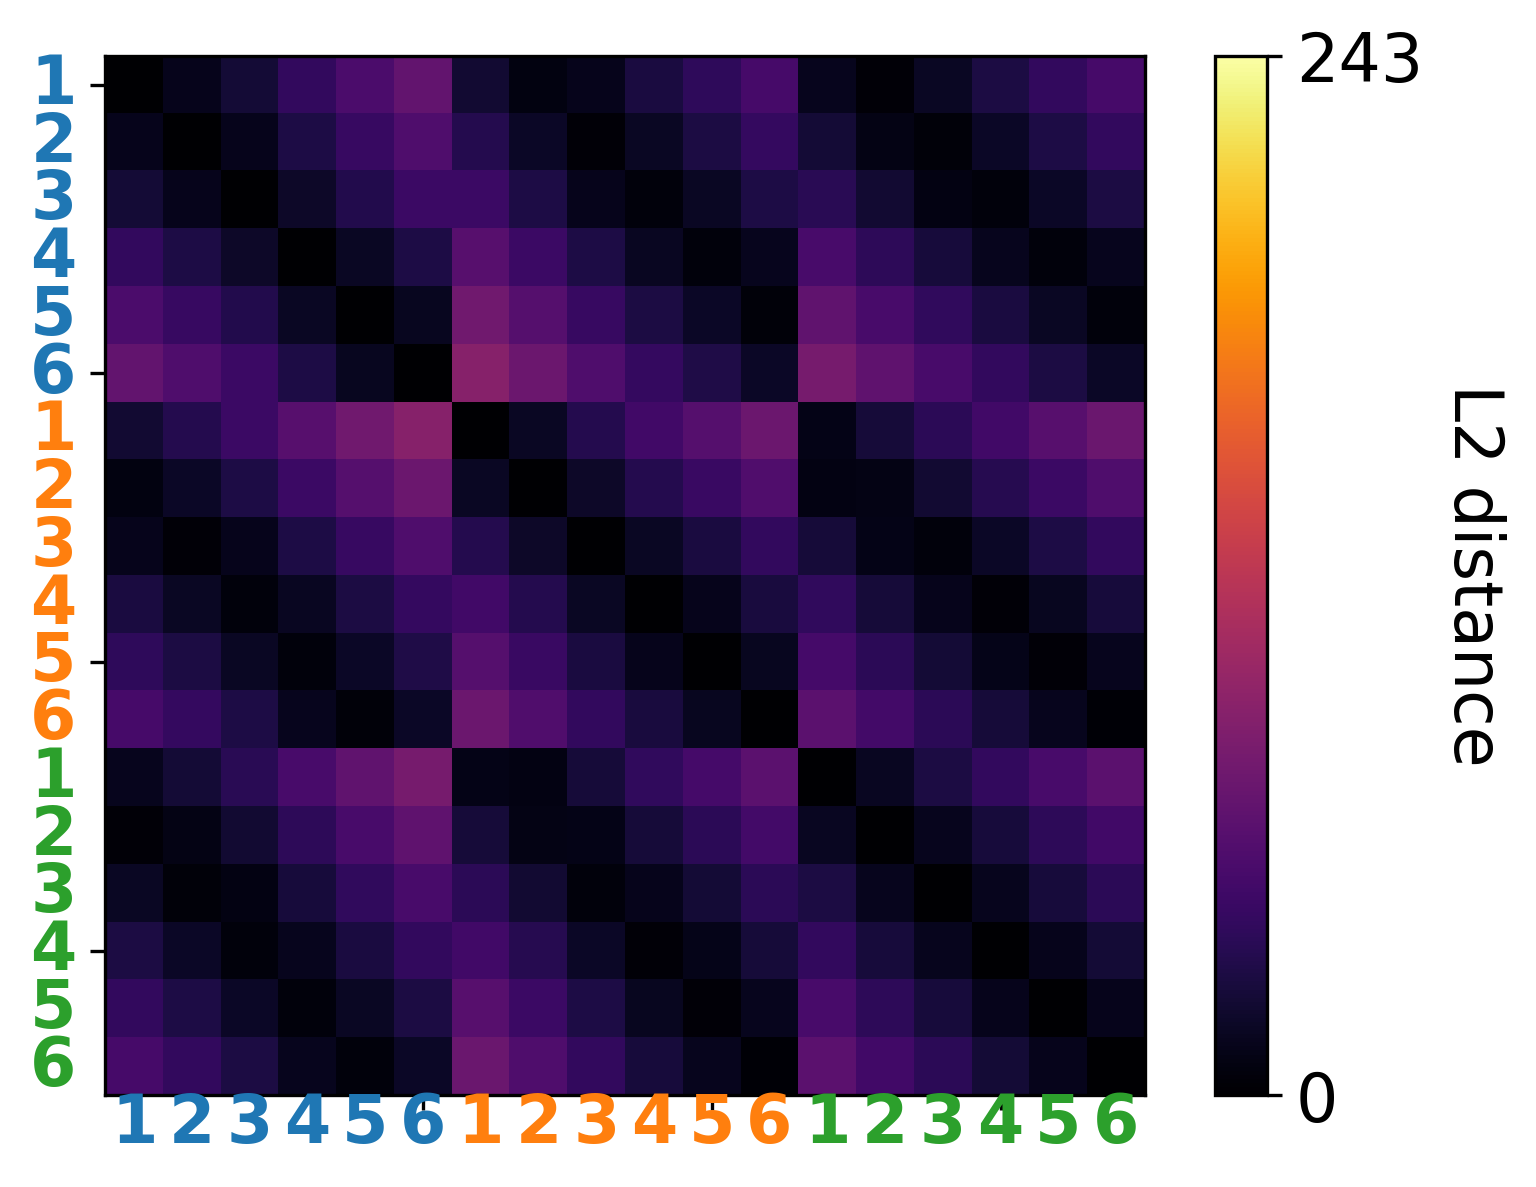

89.41153885187356


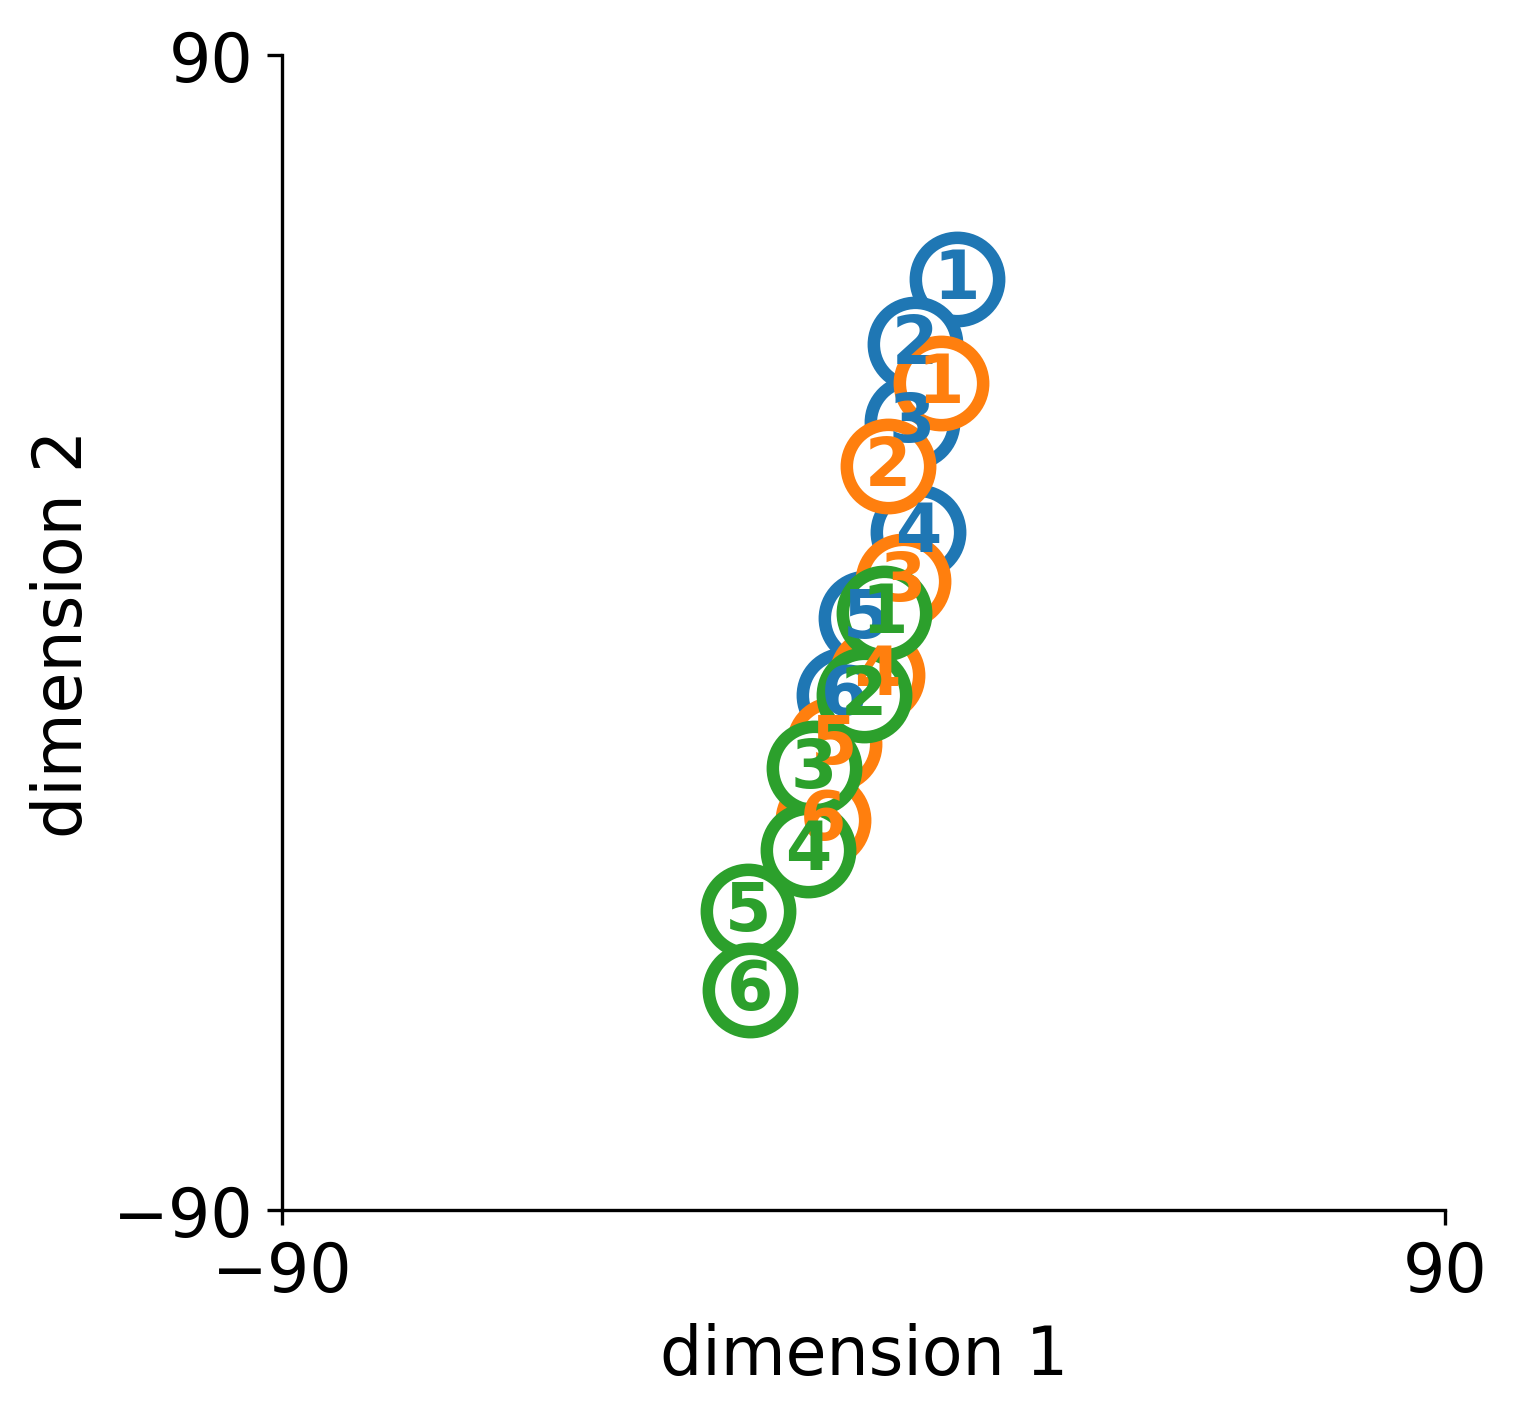

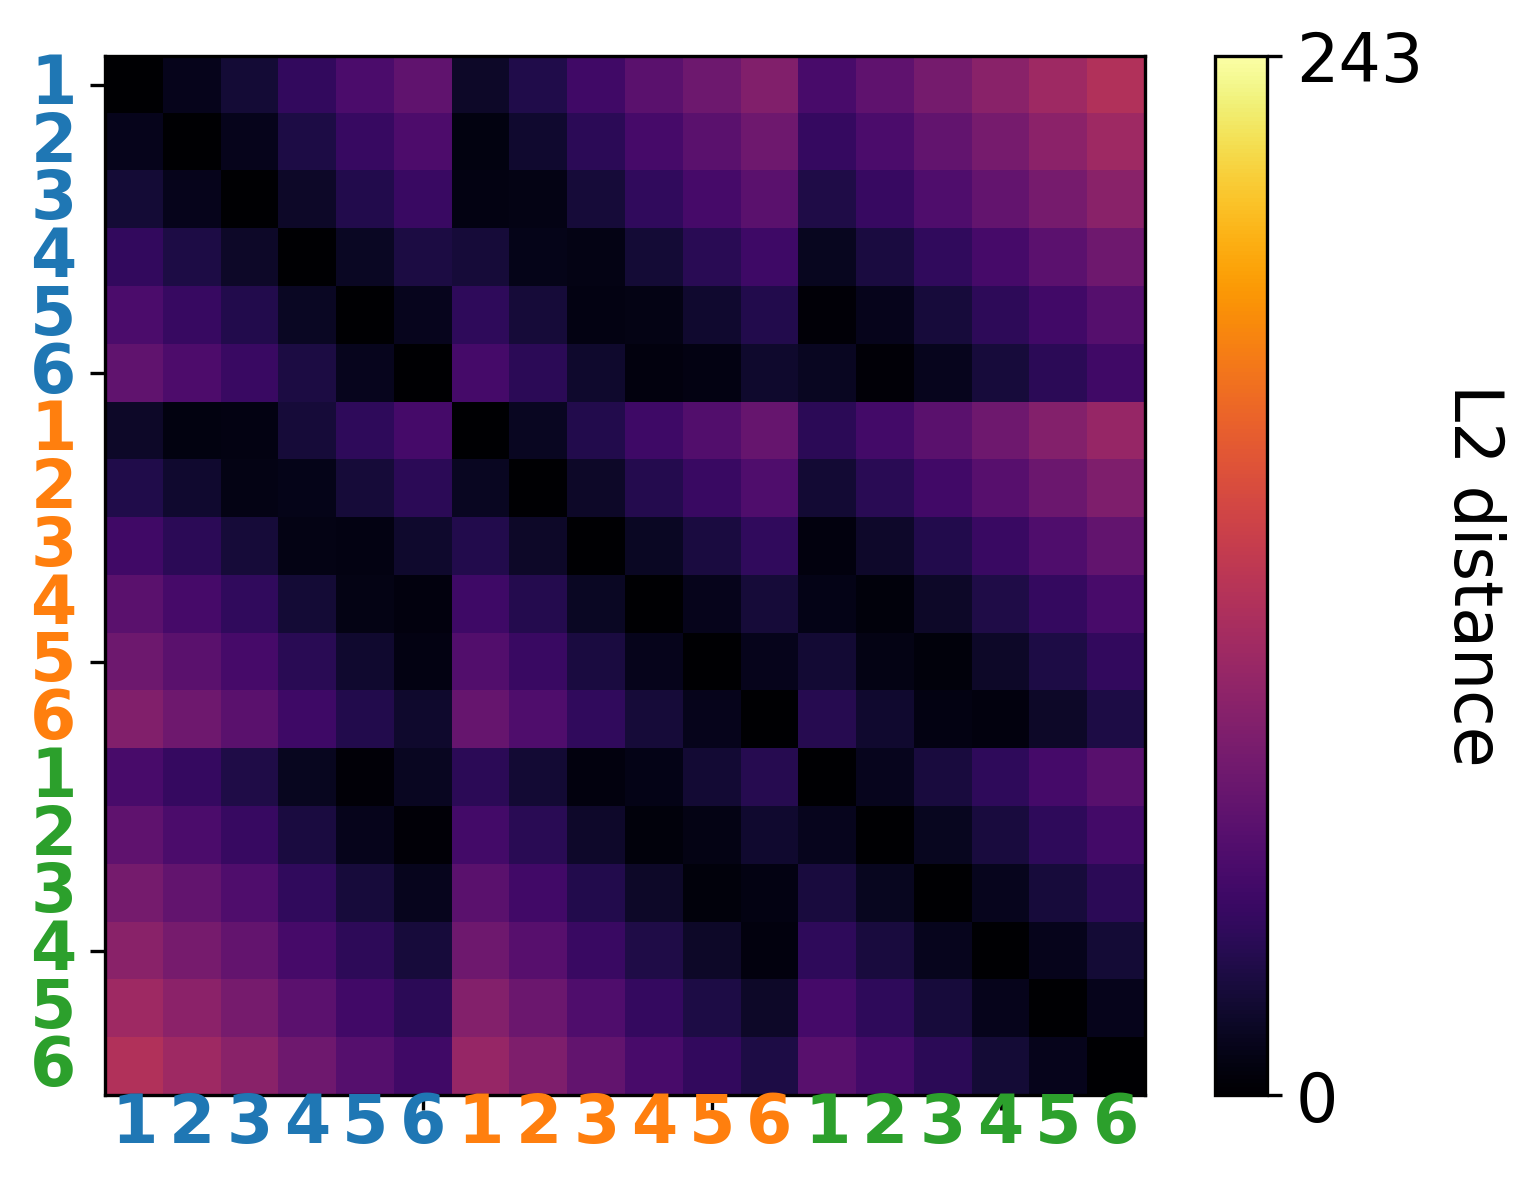

115.36460673276714


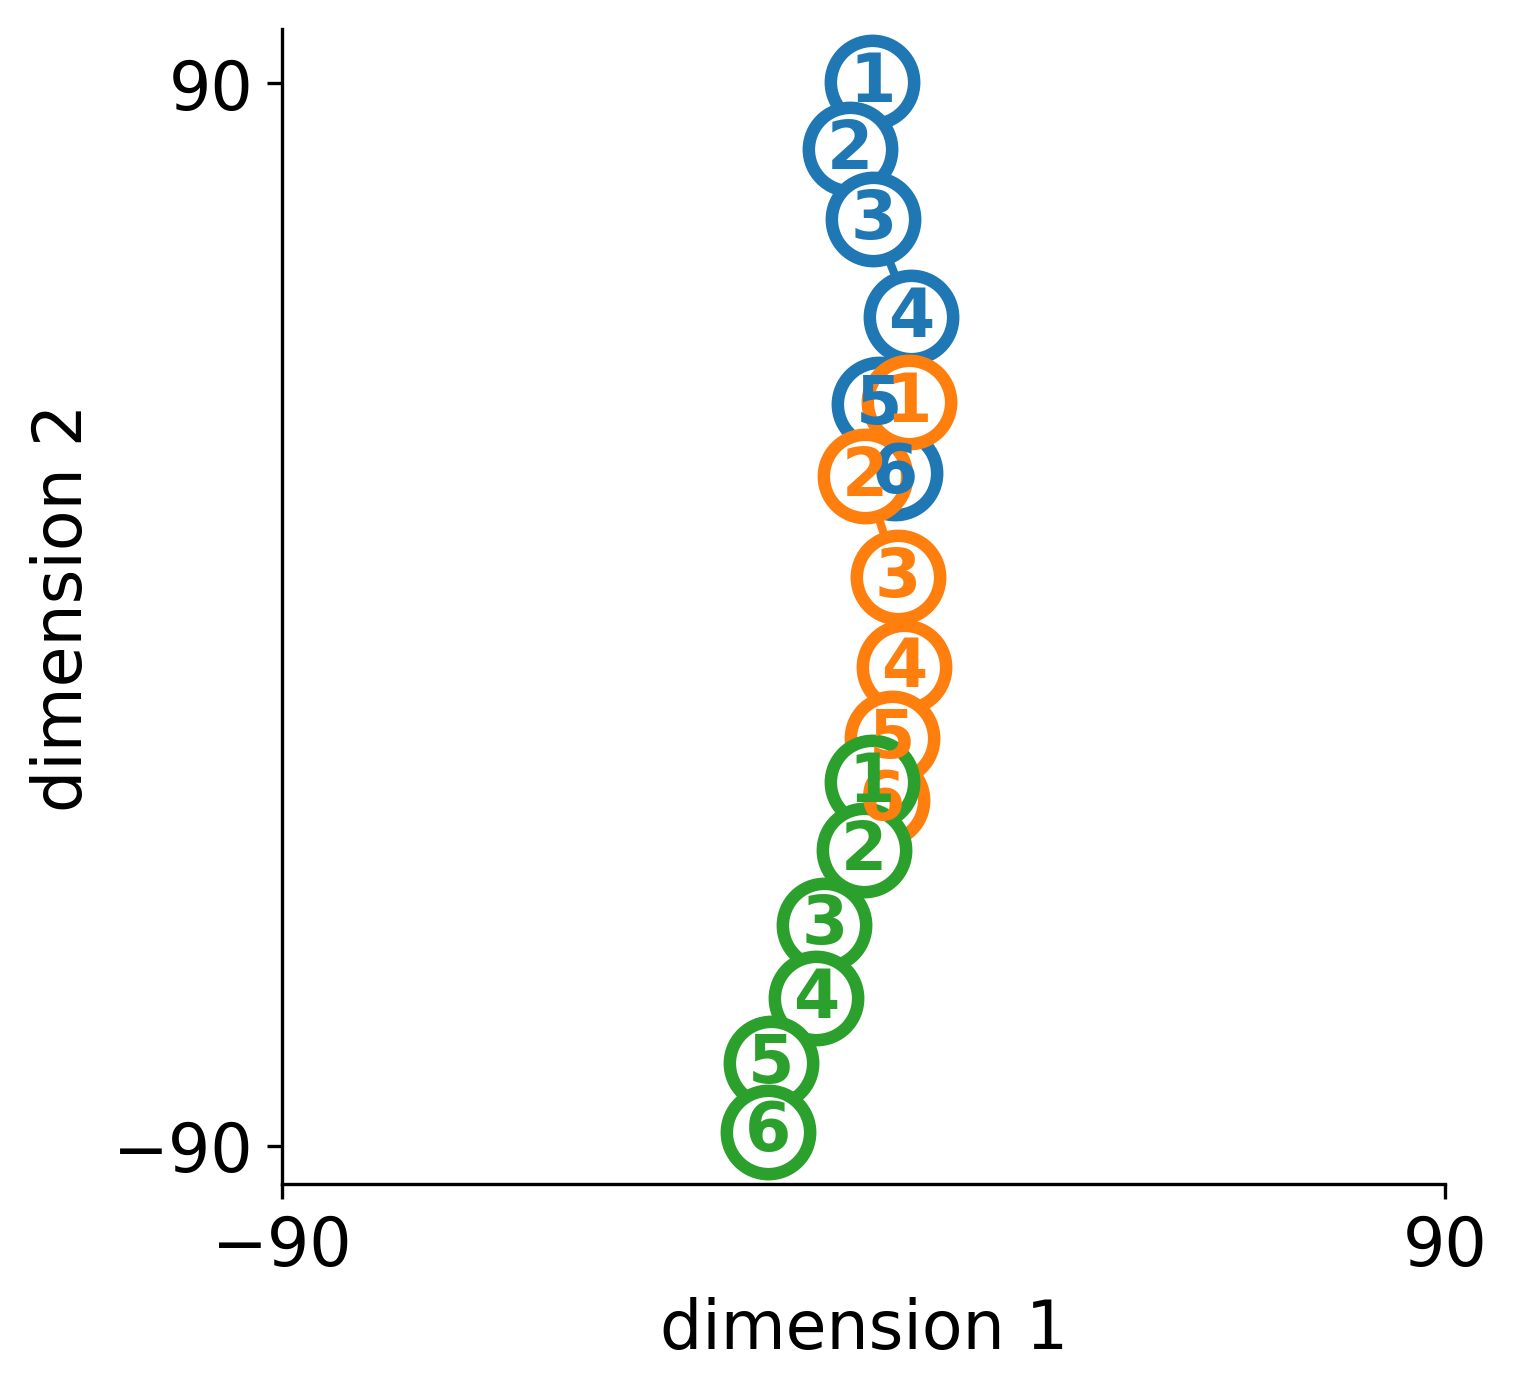

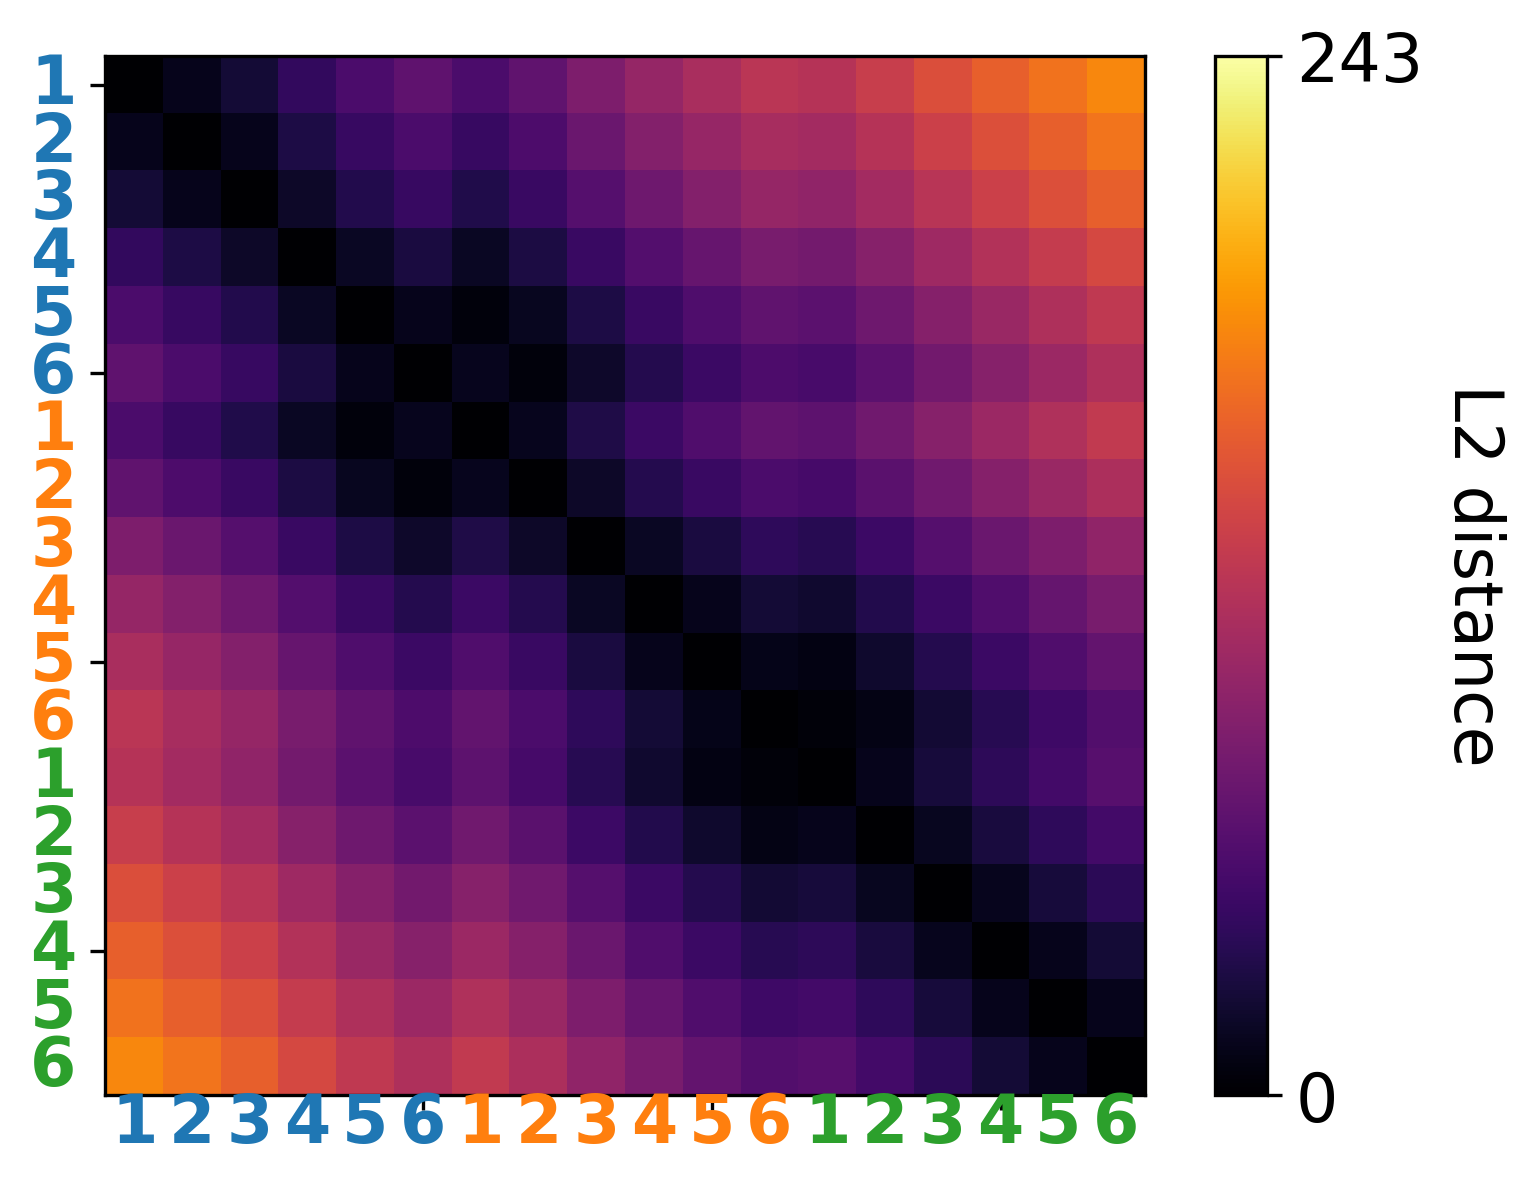

179.35594125950817


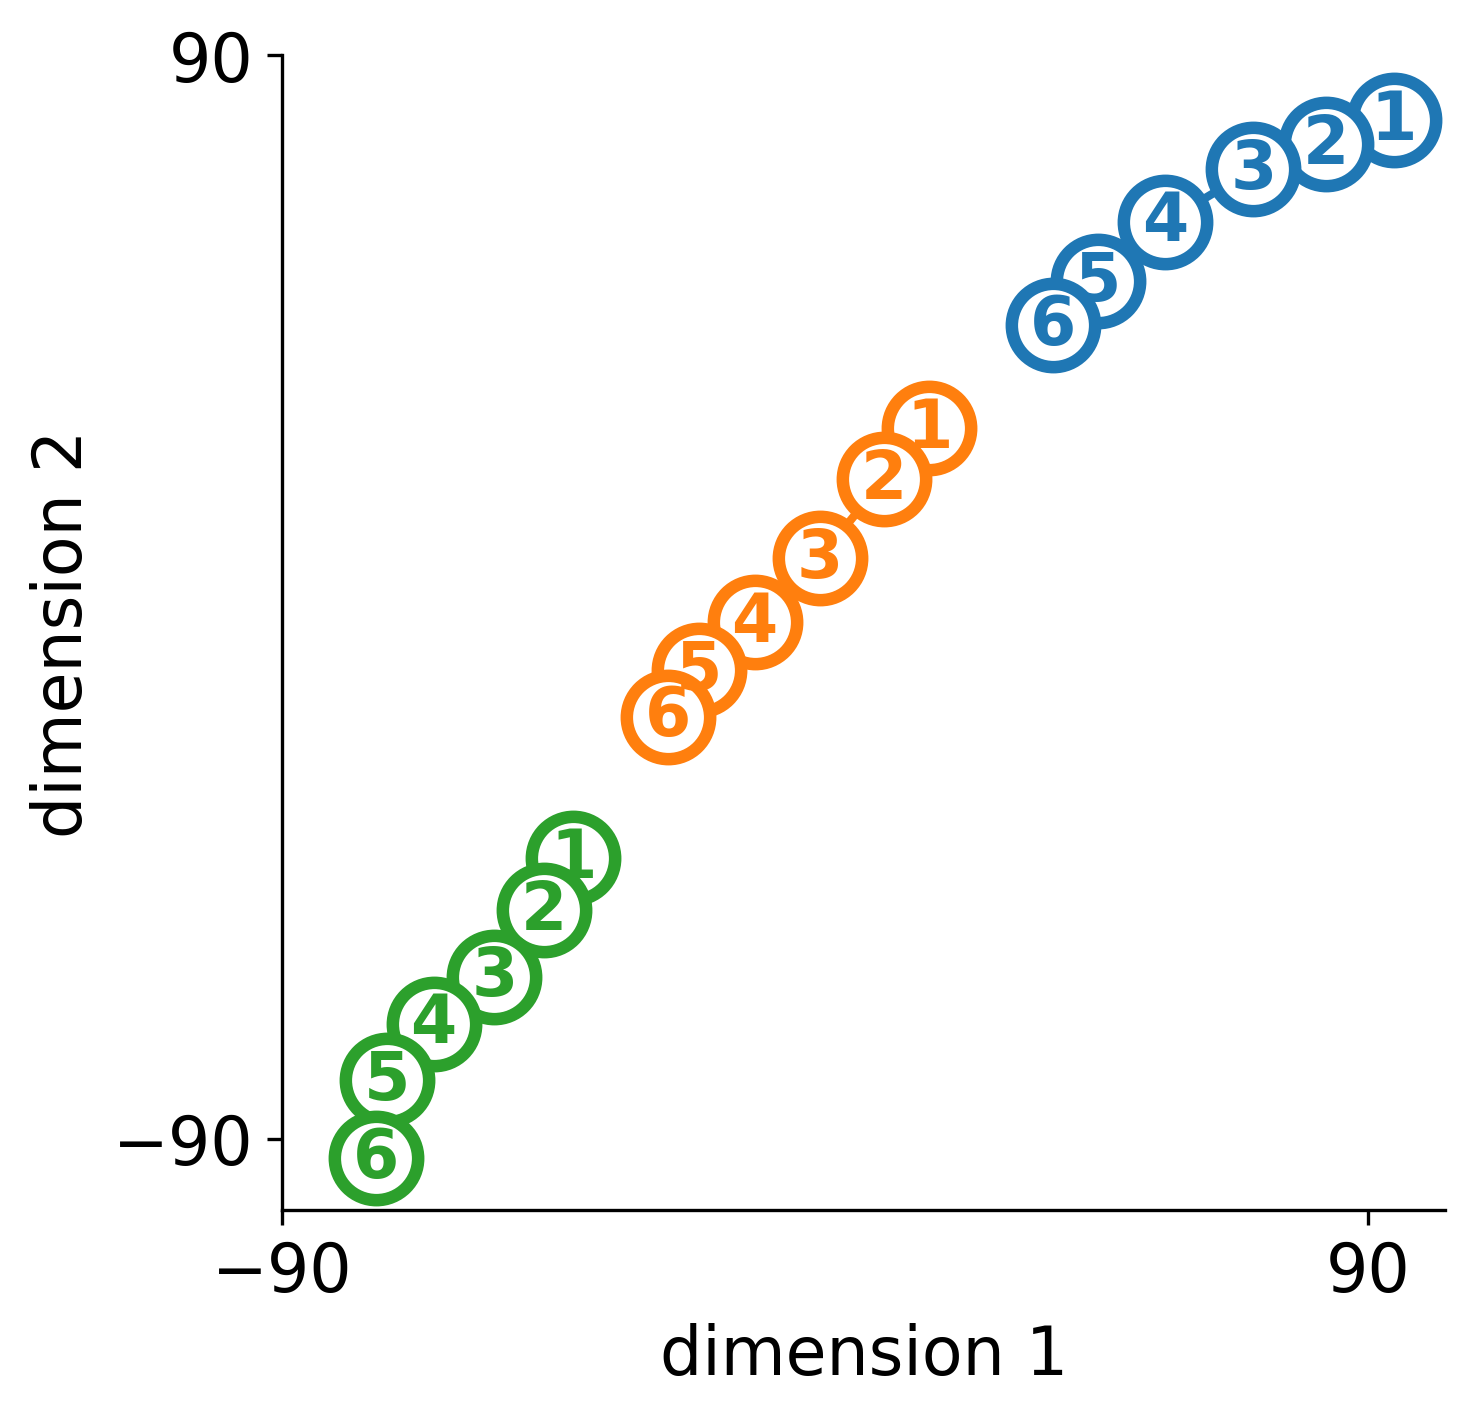

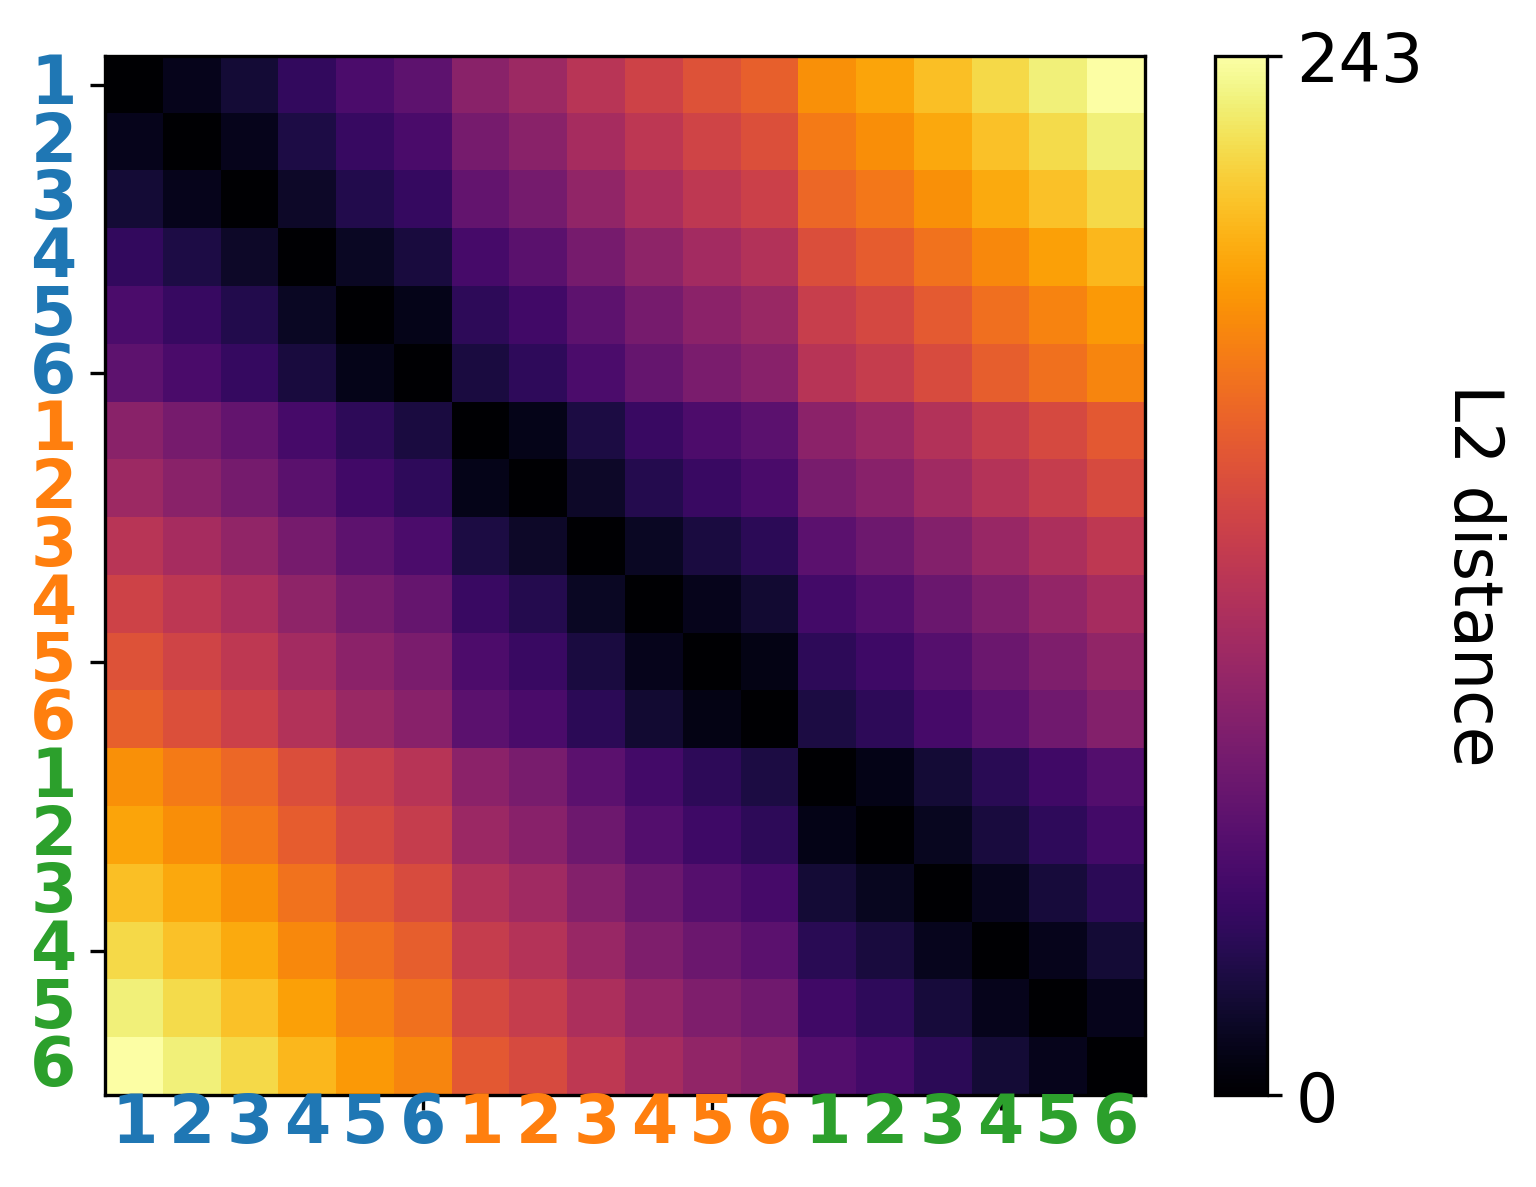

243.3518312116498


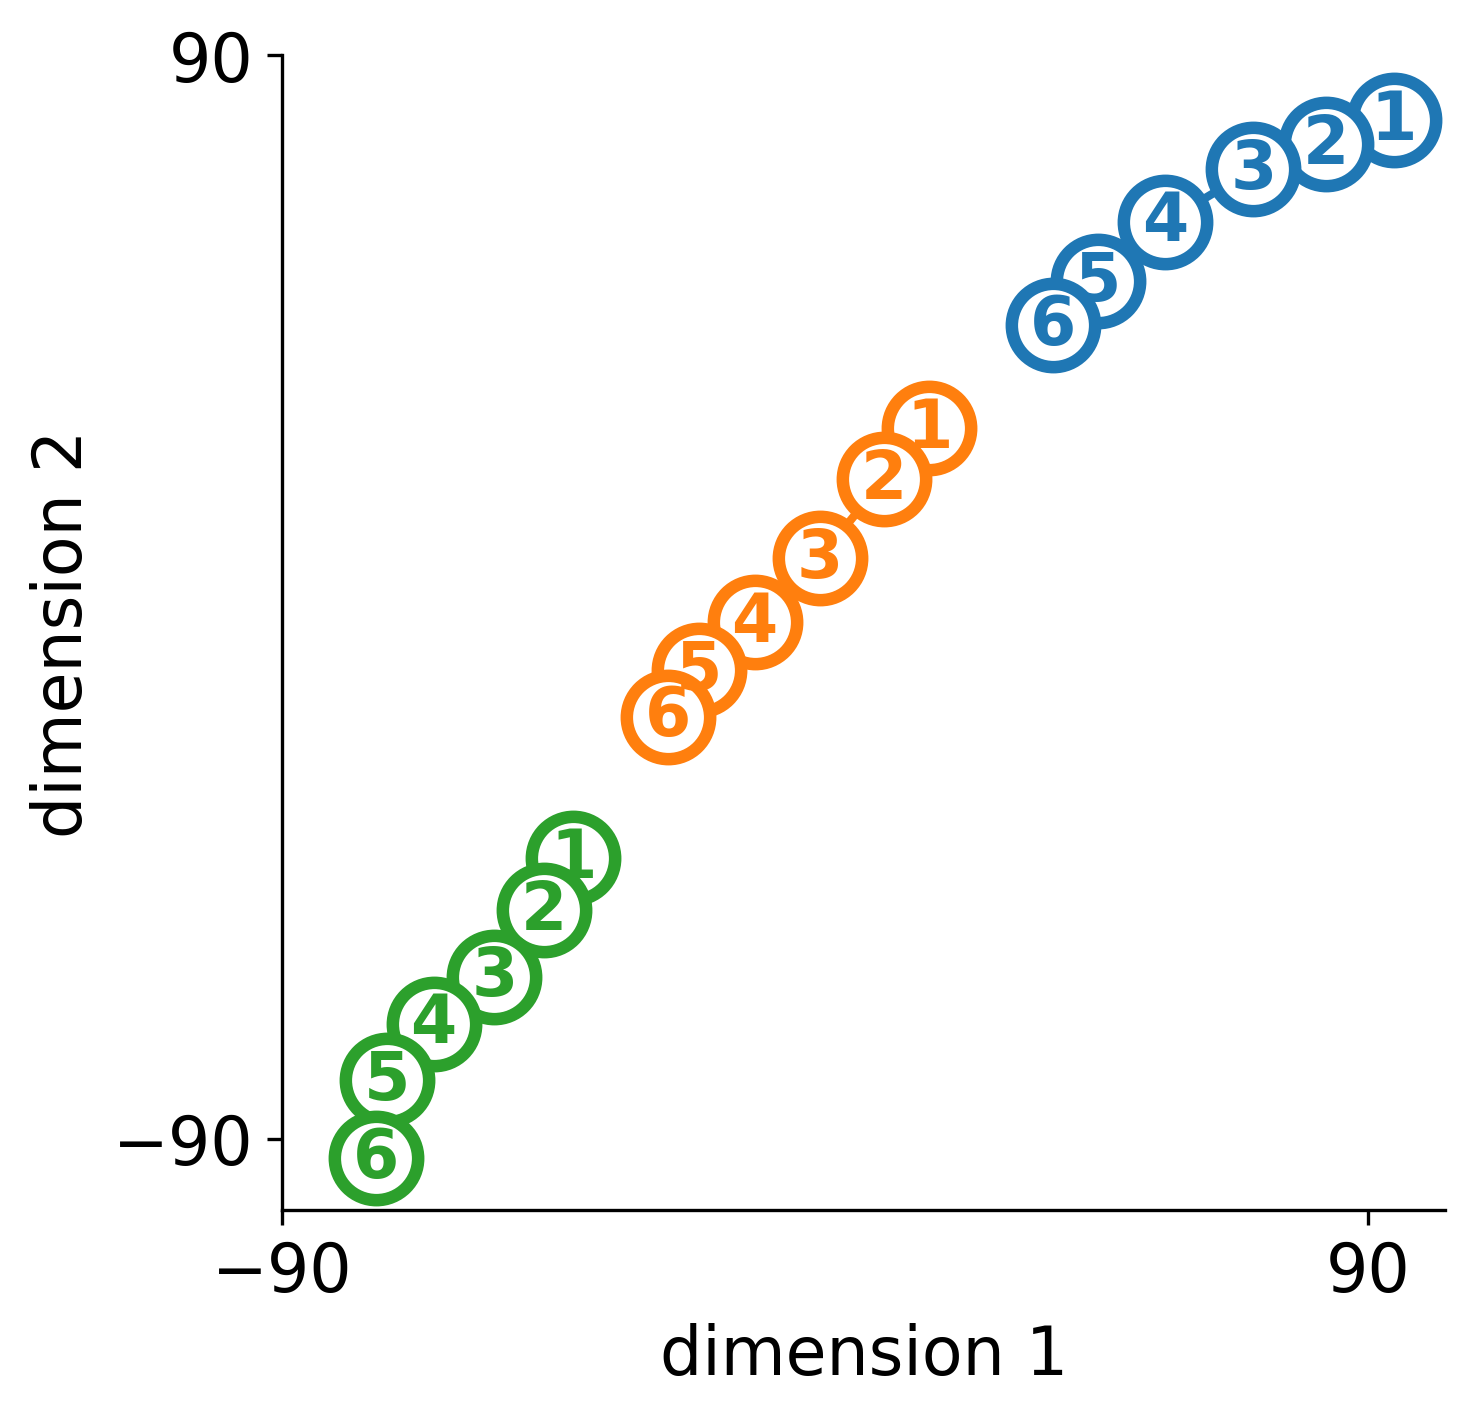

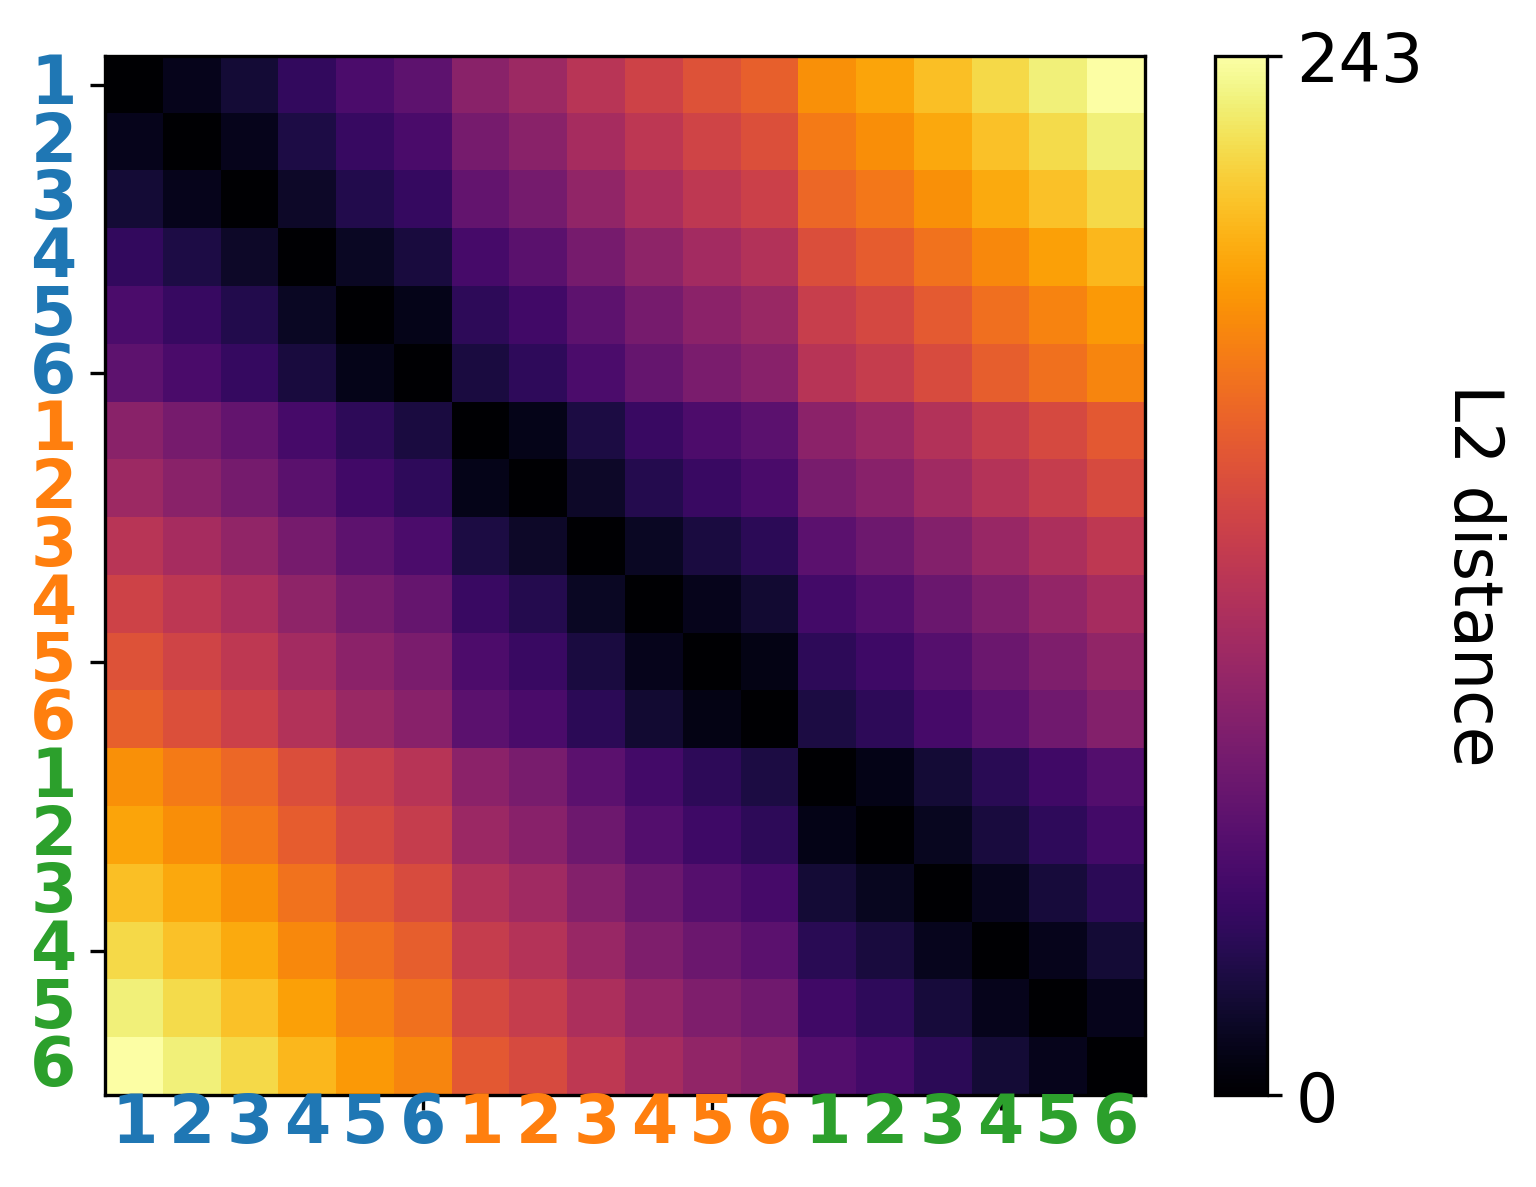

243.3518312116498


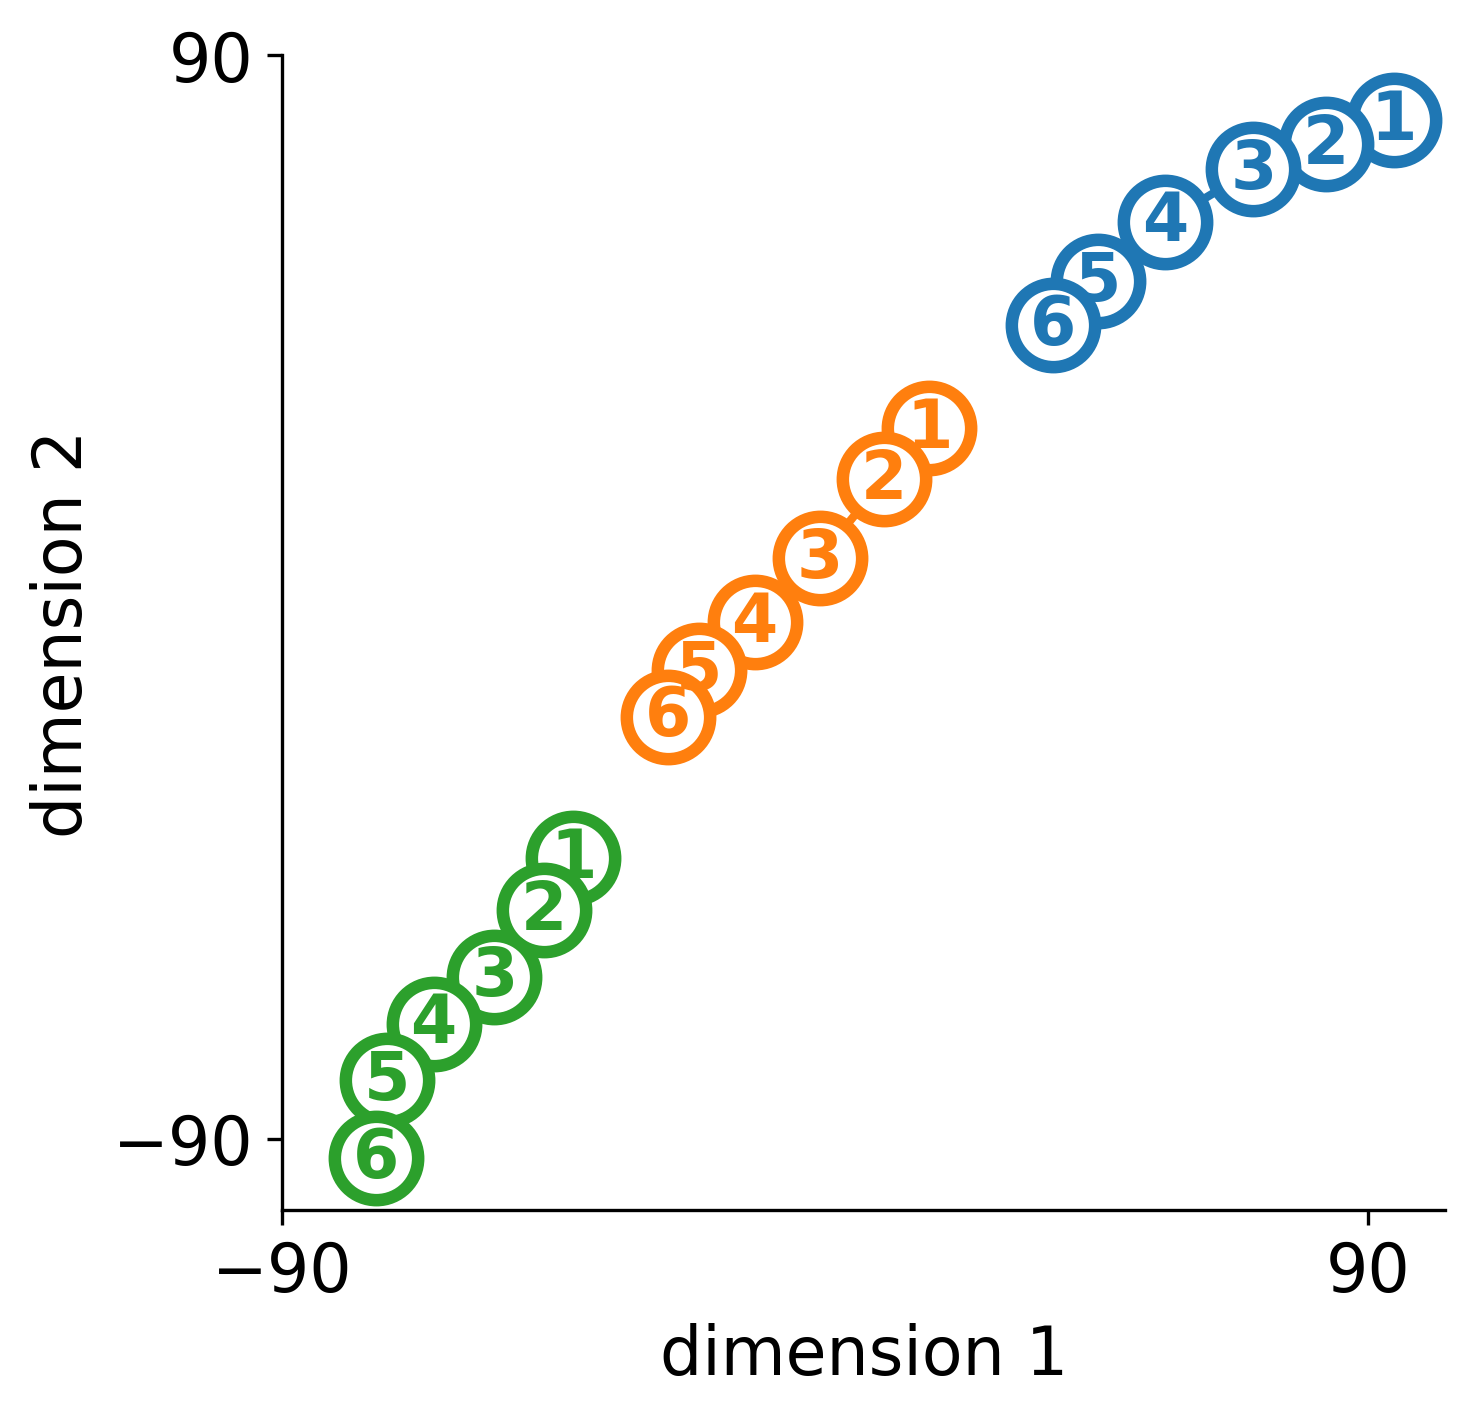

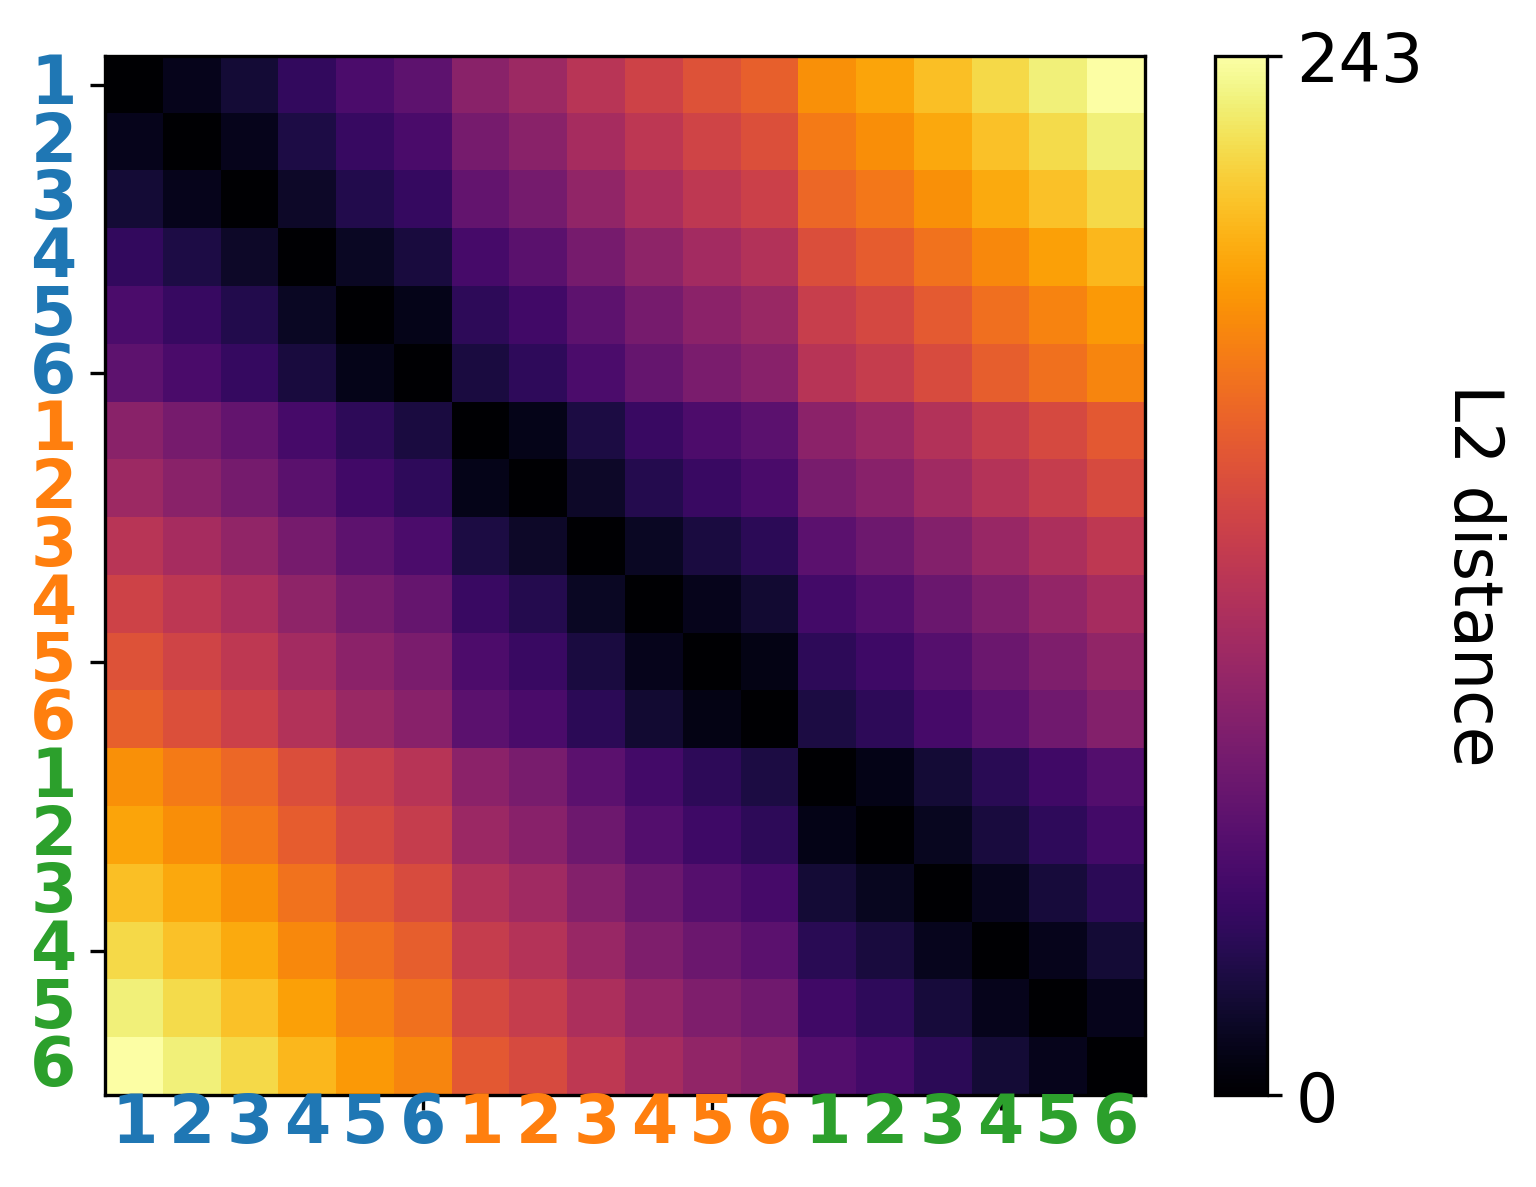

243.3518312116498


In [33]:
# =========================
# Complete runnable code
# Phase 1: learn 3 ranks separately (3 contexts)
# Phase 2: use two boundary pairs to stack contexts into one global rank
# =========================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from scipy.spatial.distance import cdist
from sklearn.utils import shuffle
from tqdm.notebook import tqdm
import torch

plt.rcParams.update({'font.size': 16})

# -------------------------
# Core forward + visualization
# -------------------------
def forward(x, W, P, Wc, c):
    # x: (num_objects, num_objects) one-hot batch
    # W: (hidden_dim, num_objects)
    # Wc: (hidden_context_dim, context_dim)
    states = torch.concatenate(
        (W @ x, Wc[:, c][None].T.repeat(1, x.shape[1])),
        dim=0
    )
    output = (P @ states)  # (output_dim, num_objects)
    return output

def fig_MDS_3(W1, W2, W3, P, Wc, scale, plot=True):
    list_len = 6
    data = torch.eye(list_len)

    out1 = forward(data, W1, P, Wc, 0)
    out2 = forward(data, W2, P, Wc, 1)
    out3 = forward(data, W3, P, Wc, 2)

    data_np = np.hstack((
        out1.detach().cpu().numpy(),
        out2.detach().cpu().numpy(),
        out3.detach().cpu().numpy()
    ))  # (output_dim, 18)

    mds = MDS(n_components=2, random_state=0)
    data_2d = mds.fit_transform(data_np.T)
    data_2d[:, [0, 1]] = data_2d[:, [1, 0]]

    if not plot:
        return data_2d.max(), (out1, out2, out3)

    colors = ['tab:blue', 'tab:orange', 'tab:green']
    fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
    dot_size = 400
    dot_edge_width = 3

    for ctx, col in enumerate(colors):
        start = ctx * list_len
        end = (ctx + 1) * list_len

        for i in range(start + 1, end):
            ax.plot(
                data_2d[i-1:i+1, 0],
                data_2d[i-1:i+1, 1],
                color=col,
                linewidth=2,
                zorder=1
            )

        for i, point in enumerate(data_2d[start:end, :]):
            ax.scatter(
                point[0], point[1],
                s=dot_size,
                edgecolor=col,
                facecolor='white',
                linewidth=dot_edge_width,
                zorder=2
            )
            ax.text(
                point[0], point[1],
                str(i + 1),
                color=col,
                ha='center',
                va='center',
                fontweight='bold',
                zorder=3
            )

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ticks = [-scale, scale]
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    plt.xlabel('dimension 1')
    plt.ylabel('dimension 2')
    plt.show()

    return (out1, out2, out3)

def plot_heat_map_3(out1, out2, out3, max_v, plot=True):
    labels = ['1', '2', '3', '4', '5', '6'] * 3
    colors = (['tab:blue'] * 6) + (['tab:orange'] * 6) + (['tab:green'] * 6)

    all_data = np.concatenate(
        (out1.detach().cpu().numpy(), out2.detach().cpu().numpy(), out3.detach().cpu().numpy()),
        axis=1
    )  # (output_dim, 18)

    distances = cdist(all_data.T, all_data.T, 'euclidean')
    np.fill_diagonal(distances, 0)

    if not plot:
        return distances.max()

    fig, ax = plt.subplots(figsize=(4*1.5, 3*1.5), dpi=300)
    heatmap = ax.imshow(distances, cmap='inferno', origin='upper', vmin=0, vmax=max_v)

    cbar = fig.colorbar(heatmap, ticks=[0, max_v])
    cbar.set_label('L2 distance', rotation=270, labelpad=20)

    ax.set_xticklabels([])
    ax.set_yticklabels([])

    n = len(labels)
    for idx, lab in enumerate(labels):
        ax.text(idx, n, lab, va='center', ha='center', color=colors[idx], fontweight='bold')
        ax.text(-1, idx, lab, va='center', ha='right', color=colors[idx], fontweight='bold')

    ax.grid(False)
    plt.show()
    print(distances.max())
    return distances.max()

# -------------------------
# Sparse code generator (your original helper)
# -------------------------
def average_cosine(vectors):
    vectors_norm = vectors / vectors.norm(dim=1, keepdim=True)
    cosine_sim = vectors_norm @ vectors_norm.T
    n = vectors.shape[0]
    i, j = torch.triu_indices(n, n, offset=1)
    return cosine_sim[i, j].mean().item()

def gen_W(num_objects, dim, target_cosine):
    sparsity_range = (0.002, 0.01)
    vectors = torch.zeros((num_objects, dim), dtype=torch.float)
    num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
    for i in range(num_objects):
        ones_indices = torch.randperm(dim)[:num_ones[i]]
        vectors[i, ones_indices] = 1

    cos = average_cosine(vectors)
    if target_cosine == 0 and cos != 0:
        vectors = torch.zeros((num_objects, dim), dtype=torch.float)
        num_ones = torch.randint(int(sparsity_range[0] * dim), int(sparsity_range[1] * dim + 1), (num_objects,))
        for i in range(num_objects):
            ones_indices = torch.randperm(dim)[:num_ones[i]]
            vectors[i, ones_indices] = 1
        cos = average_cosine(vectors)

    while cos < target_cosine:
        indices = torch.randperm(num_objects)[:2]
        i, j = indices[0], indices[1]
        vi = vectors[i, :]
        vj = vectors[j, :]

        diff_indices = torch.nonzero(vi.int() ^ vj.int()).flatten()
        if len(diff_indices) == 0:
            continue

        dim_to_change = diff_indices[torch.randint(len(diff_indices), (1,)).item()]
        index_to_modify = i if vi[dim_to_change] == 0 else j
        vectors[index_to_modify, dim_to_change] = 1

        ones_indices = torch.nonzero(vectors[index_to_modify] == 1).flatten()
        ones_indices = ones_indices[ones_indices != dim_to_change]
        dim_to_zero = ones_indices[torch.randint(len(ones_indices), (1,)).item()]
        vectors[index_to_modify, dim_to_zero] = 0

        cos = average_cosine(vectors)

    return vectors.T

# -------------------------
# Your error function
# -------------------------
def error_function(v_i, v_j, label):
    # label in {+1,-1}
    # sign(max(label*(v_i-v_j)+1,0) * label)
    return torch.sign(torch.maximum((label * (v_i - v_j) + 1), torch.tensor(0.0, device=v_i.device)) * label)

# -------------------------
# Setup
# -------------------------
torch.manual_seed(1)
np.random.seed(1)

num_objects = 6
input_dim = num_objects
context_dim = 3
hidden_dim = 1000
hidden_context_dim = 1000
output_dim = 100

one_hot_vectors1 = torch.eye(num_objects)
one_hot_vectors2 = torch.eye(num_objects)
one_hot_vectors3 = torch.eye(num_objects)
one_hot_context = torch.eye(context_dim)

cos = 0
W1 = gen_W(num_objects, hidden_dim, cos)
W2 = gen_W(num_objects, hidden_dim, cos)
W3 = gen_W(num_objects, hidden_dim, cos)
Wc = gen_W(context_dim, hidden_context_dim, cos)

P = torch.randn(output_dim, hidden_dim + hidden_context_dim) * 0.0001

ground_truth_ranking1 = [0, 1, 2, 3, 4, 5]
ground_truth_ranking2 = [0, 1, 2, 3, 4, 5]
ground_truth_ranking3 = [0, 1, 2, 3, 4, 5]

pairs1 = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
pairs2 = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]
pairs3 = [(i, j) for i in range(num_objects) for j in range(num_objects) if i != j]

labels1 = [(1 if ground_truth_ranking1.index(i) < ground_truth_ranking1.index(j) else -1) for i, j in pairs1]
labels2 = [(1 if ground_truth_ranking2.index(i) < ground_truth_ranking2.index(j) else -1) for i, j in pairs2]
labels3 = [(1 if ground_truth_ranking3.index(i) < ground_truth_ranking3.index(j) else -1) for i, j in pairs3]

# -------------------------
# Phase 1: within-context training (3 contexts)
# -------------------------
eta_phase1 = 0.1
num_epochs_phase1 = 10

def mean_v_context(W, c_idx, one_hot_vectors):
    mv = np.zeros(num_objects)
    for i in range(num_objects):
        s_i_s = W @ one_hot_vectors[i]
        s_i_c = Wc @ one_hot_context[c_idx]
        s_i = torch.concatenate((s_i_s, s_i_c))
        v_i = P @ s_i
        mv[i] = v_i.mean().item()
    return mv

mean_v_values1 = np.zeros((num_epochs_phase1 * len(pairs1) + 1, num_objects))
mean_v_values2 = np.zeros((num_epochs_phase1 * len(pairs1) + 1, num_objects))
mean_v_values3 = np.zeros((num_epochs_phase1 * len(pairs1) + 1, num_objects))

mean_v_values1[0, :] = mean_v_context(W1, 0, one_hot_vectors1)
mean_v_values2[0, :] = mean_v_context(W2, 1, one_hot_vectors2)
mean_v_values3[0, :] = mean_v_context(W3, 2, one_hot_vectors3)

P_record_phase1 = []
iters = 0

for epoch in tqdm(range(num_epochs_phase1), desc="Phase 1 training (3 contexts)"):
    if epoch in [1, 3, 5, 9]:
        P_record_phase1 += [P.clone()]

    pairs1_s, labels1_s = shuffle(pairs1, labels1)
    pairs2_s, labels2_s = shuffle(pairs2, labels2)
    pairs3_s, labels3_s = shuffle(pairs3, labels3)

    for (i1, j1), lab1, (i2, j2), lab2, (i3, j3), lab3 in zip(pairs1_s, labels1_s, pairs2_s, labels2_s, pairs3_s, labels3_s):
        # ctx1 update
        s_i1 = torch.concatenate((W1 @ one_hot_vectors1[i1], Wc @ one_hot_context[0]))
        s_j1 = torch.concatenate((W1 @ one_hot_vectors1[j1], Wc @ one_hot_context[0]))
        v_i1 = P @ s_i1
        v_j1 = P @ s_j1
        e1 = error_function(v_i1, v_j1, lab1)
        P += eta_phase1 * torch.outer(e1, (s_j1 - s_i1))

        # ctx2 update
        s_i2 = torch.concatenate((W2 @ one_hot_vectors2[i2], Wc @ one_hot_context[1]))
        s_j2 = torch.concatenate((W2 @ one_hot_vectors2[j2], Wc @ one_hot_context[1]))
        v_i2 = P @ s_i2
        v_j2 = P @ s_j2
        e2 = error_function(v_i2, v_j2, lab2)
        P += eta_phase1 * torch.outer(e2, (s_j2 - s_i2))

        # ctx3 update
        s_i3 = torch.concatenate((W3 @ one_hot_vectors3[i3], Wc @ one_hot_context[2]))
        s_j3 = torch.concatenate((W3 @ one_hot_vectors3[j3], Wc @ one_hot_context[2]))
        v_i3 = P @ s_i3
        v_j3 = P @ s_j3
        e3 = error_function(v_i3, v_j3, lab3)
        P += eta_phase1 * torch.outer(e3, (s_j3 - s_i3))

        mean_v_values1[iters + 1, :] = mean_v_context(W1, 0, one_hot_vectors1)
        mean_v_values2[iters + 1, :] = mean_v_context(W2, 1, one_hot_vectors2)
        mean_v_values3[iters + 1, :] = mean_v_context(W3, 2, one_hot_vectors3)
        iters += 1

P_record_phase1 += [P.clone()]

# Check learned ranks after phase 1
sv1 = mean_v_values1[-1, :]
sv2 = mean_v_values2[-1, :]
sv3 = mean_v_values3[-1, :]
lr1 = sorted(range(num_objects), key=lambda i: sv1[i])
lr2 = sorted(range(num_objects), key=lambda i: sv2[i])
lr3 = sorted(range(num_objects), key=lambda i: sv3[i])

print("Phase 1")
print("ctx1 learned:", lr1, "mean v:", sv1)
print("ctx2 learned:", lr2, "mean v:", sv2)
print("ctx3 learned:", lr3, "mean v:", sv3)

# -------------------------
# Phase 2: boundary stacking (your style, extended to 3 contexts)
# Two boundary pairs:
# ctx1 worst vs ctx2 best, label=+1
# ctx2 worst vs ctx3 best, label=+1
# -------------------------
num_epochs_phase2 = 5
eta_phase2 = 0.02
context_learning_rate_ratio = 20

values_all = np.zeros((num_epochs_phase2 + 1, num_objects * 3))

mean_v_values1_b = np.zeros((num_epochs_phase2 + 2, num_objects))
mean_v_values2_b = np.zeros((num_epochs_phase2 + 2, num_objects))
mean_v_values3_b = np.zeros((num_epochs_phase2 + 2, num_objects))

mean_v_values1_b[0, :] = mean_v_context(W1, 0, one_hot_vectors1)
mean_v_values2_b[0, :] = mean_v_context(W2, 1, one_hot_vectors2)
mean_v_values3_b[0, :] = mean_v_context(W3, 2, one_hot_vectors3)

P_record_phase2 = []
for epoch in tqdm(range(num_epochs_phase2 + 1), desc="Phase 2 boundary stacking (3 contexts)"):
    P_record_phase2 += [P.clone()]

    for obj in range(num_objects):
        values_all[epoch, obj] = (P @ torch.concatenate((W1 @ one_hot_vectors1[obj], Wc @ one_hot_context[0]))).mean()
        values_all[epoch, obj + num_objects] = (P @ torch.concatenate((W2 @ one_hot_vectors2[obj], Wc @ one_hot_context[1]))).mean()
        values_all[epoch, obj + 2 * num_objects] = (P @ torch.concatenate((W3 @ one_hot_vectors3[obj], Wc @ one_hot_context[2]))).mean()

    # boundary 1: ctx2 best above ctx1 worst
    s_boundary_low_12 = torch.concatenate((W1 @ one_hot_vectors1[-1], Wc @ one_hot_context[0]))
    s_new_12 = torch.concatenate((W2 @ one_hot_vectors2[0],  Wc @ one_hot_context[1]))

    v_boundary_low_12 = P @ s_boundary_low_12
    v_new_12 = P @ s_new_12

    e12 = error_function(v_boundary_low_12, v_new_12, 1)

    d12 = (s_new_12 - s_boundary_low_12)
    P[:, :hidden_dim] += eta_phase2 * torch.outer(e12, d12[:hidden_dim])
    P[:, hidden_dim:] += context_learning_rate_ratio * eta_phase2 * torch.outer(e12, d12[hidden_dim:])

    # boundary 2: ctx3 best above ctx2 worst
    s_boundary_low_23 = torch.concatenate((W2 @ one_hot_vectors2[-1], Wc @ one_hot_context[1]))
    s_new_23 = torch.concatenate((W3 @ one_hot_vectors3[0],  Wc @ one_hot_context[2]))

    v_boundary_low_23 = P @ s_boundary_low_23
    v_new_23 = P @ s_new_23

    e23 = error_function(v_boundary_low_23, v_new_23, 1)

    d23 = (s_new_23 - s_boundary_low_23)
    P[:, :hidden_dim] += eta_phase2 * torch.outer(e23, d23[:hidden_dim])
    P[:, hidden_context_dim:]  # no-op line, safe to remove
    P[:, hidden_dim:] += context_learning_rate_ratio * eta_phase2 * torch.outer(e23, d23[hidden_dim:])

    mean_v_values1_b[epoch + 1, :] = mean_v_context(W1, 0, one_hot_vectors1)
    mean_v_values2_b[epoch + 1, :] = mean_v_context(W2, 1, one_hot_vectors2)
    mean_v_values3_b[epoch + 1, :] = mean_v_context(W3, 2, one_hot_vectors3)

# Check learned ranks after phase 2
sv1b = mean_v_values1_b[-1, :]
sv2b = mean_v_values2_b[-1, :]
sv3b = mean_v_values3_b[-1, :]

lr1b = sorted(range(num_objects), key=lambda i: sv1b[i])
lr2b = sorted(range(num_objects), key=lambda i: sv2b[i])
lr3b = sorted(range(num_objects), key=lambda i: sv3b[i])

print("Phase 2")
print("ctx1 learned:", lr1b, "mean v:", sv1b)
print("ctx2 learned:", lr2b, "mean v:", sv2b)
print("ctx3 learned:", lr3b, "mean v:", sv3b)

# Global ordering across all 18 items, smaller mean v = higher in rank
global_items = []
for i in range(num_objects):
    global_items.append((sv1b[i], 1, i + 1))
    global_items.append((sv2b[i], 2, i + 1))
    global_items.append((sv3b[i], 3, i + 1))
global_items = sorted(global_items, key=lambda x: x[0])

print("Global rank (small mean v = higher)")
for k, (v, c, item) in enumerate(global_items, start=1):
    print(k, "ctx", c, "item", item, "mean_v", float(v))

# -------------------------
# Visualization across checkpoints
# You can include phase1 + phase2 checkpoints in one list
# -------------------------
P_record_all = P_record_phase1 + P_record_phase2

max_mds = 0
max_heat = 0
for Ptmp in P_record_all:
    _mds, (o1, o2, o3) = fig_MDS_3(W1, W2, W3, Ptmp, Wc, 10, plot=False)
    if _mds > max_mds:
        max_mds = _mds
    _heat = plot_heat_map_3(o1, o2, o3, 99, plot=False)
    if _heat > max_heat:
        max_heat = _heat

print("max_mds:", max_mds, "max_heat:", max_heat)

for Ptmp in P_record_all:
    outs = fig_MDS_3(W1, W2, W3, Ptmp, Wc, round(max_mds, -1), plot=True)
    plot_heat_map_3(outs[0], outs[1], outs[2], round(max_heat, 0), plot=True)
